In [1]:
import matplotlib.pyplot as plt
import numpy as np

import time

import sys
import os

from datetime import datetime
import subprocess

os.environ['CUDA_VISIBLE_DEVICES']="0"


from keras.layers import Dense, Input, Dropout, BatchNormalization
from keras.models import Model, Sequential

from keras.regularizers import l2, l1, l1_l2

from sklearn.model_selection import train_test_split

import pickle


import tensorflow as tf




2025-02-10 04:26:30.826102: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-10 04:26:30.843373: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8463] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-10 04:26:30.848807: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import optree
import keras
print(optree.__version__)
print(keras.__version__)

0.13.0
3.4.1


In [3]:
print("\n\n")
print("  numpy version:  %s" % str(np.version.version) )
print("  tensorflow version:  %s" % str(tf.__version__))
print("\n\n")




  numpy version:  1.26.4
  tensorflow version:  2.17.0





In [4]:
from keras.layers import Activation

beta = 16

def custom_activation(x):
    return 0.5 * x * (1 + K.tanh( beta * 0.79788 * (x + 0.044715 * x * x * x)))

## Set model and resolution parameters

In [5]:



output_dir = 'bootstrap-all-in-one-inspect-of-1d-8a'





ndim = 1

##-------------

train_mu = [ 0.0 ]



train_rho = [ [0.0] ]






train_sig = [ 1.0 ]


##-------------


true_mu = [ 0.2 ]






true_rho  = [ [0.0] ]



true_sig = [ 0.9 ]



#--- perfect
#resolution = [ 0.00001  ]

#--- good
#resolution = [ 0.25  ]

#--- nominal
resolution = [ 0.5  ]

#--- medium bad
#resolution = [ 0.75  ]

#--- poor
#resolution = [ 1.0  ]






train_cov = np.zeros( shape=(ndim,ndim) )
true_cov  = np.zeros( shape=(ndim,ndim) )

print("\n\n\n Train covariance:")

for i in range(ndim) :
    for j in range(ndim) :
        if j < i : continue
        if i == j :
            train_cov[i][j] = train_sig[i] * train_sig[j]
            print("  %2d, %2d : diagonal  %8.4f" % (i,j, train_cov[i][j]))
        else :
            k = ndim - j - 1
            train_cov[i][j] = train_sig[i] * train_sig[j] * train_rho[i][k]
            train_cov[j][i] = train_cov[i][j]
            print("  %2d, %2d :           %8.3f * %8.3f * %8.3f = %8.4f" % 
                  (i,j, train_sig[i], train_sig[j], train_rho[i][k], train_cov[i][j]))
            
            

print("\n\n\n True covariance:")  

for i in range(ndim) :
    for j in range(ndim) :
        if j < i : continue
        if i == j :
            true_cov[i][j] = true_sig[i] * true_sig[j]
            print("  %2d, %2d : diagonal  %8.4f" % (i,j, true_cov[i][j]))
        else :
            k = ndim - j - 1
            true_cov[i][j] = true_sig[i] * true_sig[j] * true_rho[i][k]
            true_cov[j][i] = true_cov[i][j]
            print("  %2d, %2d :           %8.3f * %8.3f * %8.3f = %8.4f" % 
                  (i,j, true_sig[i], true_sig[j], true_rho[i][k], true_cov[i][j]))
            
            
                

                
#-- about 10 seconds
#ngen_train = 10000
#ngen_true =   1000              

                
#-- about 62 seconds
#ngen_train = 100000
#ngen_true =    1000       


#-- about 37  (29 in of8a)  seconds
ngen_train = 100000
ngen_true =   10000

#-- about 47  (38 in of8a)  seconds
#ngen_train = 1000000
#ngen_true =   100000

#-- about 1   (56 seconds) minute
#ngen_train = 2000000
#ngen_true =   200000

#-- about 1:50  (1:48 in of8a)
#ngen_train = 4000000
#ngen_true =   400000

#-- about 5 min
#ngen_train = 10000000
#ngen_true =   1000000







of_niter = 5

#of_niter = 10

#of_niter = 4

#of_niter = 2

#of_niter = 1



#learning_rate_setval = 0.0005
#epochs_setval = 40

#learning_rate_setval = 0.0001
#epochs_setval = 10

#learning_rate_setval = 0.00002
#epochs_setval = 40

#learning_rate_setval = 0.0005
#epochs_setval = 10

#learning_rate_setval = 0.0010
#epochs_setval = 10

#learning_rate_setval = 0.0008
#epochs_setval = 10


#learning_rate_setval = 0.0005
#epochs_setval = 20





learning_rate_setval = 0.0005

#learning_rate_setval = 0.0001

#learning_rate_setval = 0.0010

#learning_rate_setval = 0.0020

#learning_rate_setval = 0.0050






#epochs_setval = 100

epochs_setval = 50

#epochs_setval = 1

#epochs_setval = 5

#epochs_setval = 20




dropout_setval = 0.0

#dropout_setval = 0.02

#dropout_setval = 0.10

#dropout_setval = 0.20

#dropout_setval = 0.30

#dropout_setval = 0.40





#patience_setval = 5

#patience_setval = 25

#patience_setval = 200

patience_setval = -1



batch_size_setval = int( ngen_true )

#batch_size_setval = int( ngen_true/10 )

#batch_size_setval = int( ngen_true/100 )

#batch_size_setval = 512


use_batch_norm = False






units_per_layer = 50

#units_per_layer = 10

#units_per_layer = 25

#units_per_layer = 80

#units_per_layer = 40

#units_per_layer = 100

#units_per_layer = 200

#units_per_layer = 400

#units_per_layer = 800

#units_per_layer = 1000

#units_per_layer = 2000

#units_per_layer = 4000

#units_per_layer = 20000





number_of_layers = 3

#number_of_layers = 2

#number_of_layers = 1





#l1reg_kernel_setval = 0.000001

#l1reg_kernel_setval = 0.00001

#l1reg_kernel_setval = 0.000005

l1reg_kernel_setval = 0.0

#l1reg_kernel_setval = 0.0001

#l1reg_kernel_setval = 0.001




#l2reg_kernel_setval = 0.000005

l2reg_kernel_setval = 0.0

#l2reg_kernel_setval = 0.001




#l1reg_activation_setval = 0.000005

#l1reg_activation_setval = 0.0000005

#l1reg_activation_setval = 0.00000005

l1reg_activation_setval = 0.0



l2reg_activation_setval = 0.0

#l2reg_activation_setval = 0.0000005

#l2reg_activation_setval = 0.00000005

#l2reg_activation_setval = 0.000000005




#l1reg_bias_setval = 0.01

#l1reg_bias_setval = 0.00001

l1reg_bias_setval = 0.0


l2reg_bias_setval = 0.0

#l2reg_bias_setval = 0.00001




#activation_setval = 'softplus'

#activation_setval = 'relu'

#activation_setval = 'gelu'

activation_setval = custom_activation




do_bootstrap = False

n_boot_samples = 500

use_poisson_fluctuations_around_ngen_true = True




random_seed = 1


save_step2_model = True





 Train covariance:
   0,  0 : diagonal    1.0000



 True covariance:
   0,  0 : diagonal    0.8100


In [6]:
try:
    os.mkdir( output_dir )
except:
    print('\n\n Output directory already exists:  %s' % output_dir)
    #print('\n\n HALTING EXECUTION\n\n')
    #sys.exit()

In [7]:
print("\n\n")
print("Train covariance determinant:  %f" % np.linalg.det( train_cov ) )
print("True covariance determinant:   %f" % np.linalg.det( true_cov ) )
print("\n\n")




Train covariance determinant:  1.000000
True covariance determinant:   0.810000





In [8]:
train_cov_inv = np.linalg.inv( train_cov )

In [9]:
train_cov_inv_test = np.matmul( train_cov, train_cov_inv )

In [10]:
print("\n\n")
print(" Train covariance")
print( train_cov )
print("\n Train covariance inverse")
print( train_cov_inv )
print("\n Train covariance inverse test")
print(train_cov_inv_test)
print("\n\n")




 Train covariance
[[1.]]

 Train covariance inverse
[[1.]]

 Train covariance inverse test
[[1.]]





In [11]:
true_cov_inv = np.linalg.inv( true_cov )

In [12]:
true_cov_inv_test = np.matmul( true_cov, true_cov_inv )

In [13]:
print("\n\n")
print(" True covariance")
print( true_cov )
print("\n True covariance inverse")
print( true_cov_inv )
print("\n True covariance inverse test")
print(true_cov_inv_test)
print("\n\n")




 True covariance
[[0.81]]

 True covariance inverse
[[1.2345679]]

 True covariance inverse test
[[1.]]





## Generate samples, save events and config

In [14]:

np.random.seed( random_seed )
keras.utils.set_random_seed( random_seed )



train_pts = np.random.multivariate_normal(train_mu, train_cov, size=ngen_train)
true_pts = np.random.multivariate_normal(true_mu, true_cov, size=ngen_true)

train_det_pts = np.random.normal( train_pts, resolution )

true_det_pts = np.random.normal( true_pts, resolution )


true_pts10x = np.random.multivariate_normal(true_mu, true_cov, size=ngen_true*40)
true_det_pts10x = np.random.normal( true_pts10x, resolution )
true_pts10x_weights = np.ones( ngen_true*40 )
true_pts10x_weights = (1./40.) * true_pts10x_weights


In [15]:
with open( '%s/train-and-true-samples.npy' % output_dir, 'wb') as f :
    np.save(f, train_pts)
    np.save(f, train_det_pts)
    np.save(f, true_pts)
    np.save(f, true_det_pts)

In [16]:
with open( '%s/config-pars.npy' % output_dir , 'wb' ) as f :
    np.save( f, train_mu )
    np.save( f, train_rho )
    np.save( f, train_sig )
    np.save( f, true_mu )
    np.save( f, true_rho )
    np.save( f, true_sig )
    np.save( f, resolution )
    np.save( f, train_cov )
    np.save( f, true_cov )

In [17]:
with open('%s/config-pars.pkl' % output_dir, 'wb') as f :
    pickle.dump( train_mu, f)
    pickle.dump( train_rho, f)
    pickle.dump( train_sig, f)
    pickle.dump( true_mu,f)
    pickle.dump( true_rho,f)
    pickle.dump( true_sig,f)
    pickle.dump( resolution,f)
    pickle.dump( train_cov,f)
    pickle.dump( true_cov,f)

In [18]:
config_filename = '%s/config.txt' % output_dir

config_file = open( config_filename, 'w' )

config_file.write('%s\n\n' % datetime.now() )
config_file.write('ngen_train %d\n' % ngen_train )
config_file.write('ngen_true  %d\n' % ngen_true )
config_file.write('of_niter   %d\n' % of_niter )
config_file.write('ndim       %d\n' % ndim )
config_file.write('learning_rate_setval  %f\n' % learning_rate_setval )
config_file.write('epochs_setval  %d\n' % epochs_setval )
config_file.write('batch_size_setval  %d\n' % batch_size_setval )
config_file.write( 'random_seed:  %d\n' % random_seed  )
config_file.write('l1reg_kernel_setval  %s\n' % l1reg_kernel_setval )
config_file.write('l2reg_kernel_setval  %s\n' % l2reg_kernel_setval )
config_file.write('l1reg_activation_setval  %s\n' % l1reg_activation_setval )
config_file.write('l2reg_activation_setval  %s\n' % l2reg_activation_setval )
config_file.write('l1reg_bias_setval  %s\n' % l1reg_bias_setval )
config_file.write('l2reg_bias_setval  %s\n' % l2reg_bias_setval )
config_file.write('activation_setval  %s\n' % activation_setval )
config_file.write('beta  %s\n' % beta )



config_file.write('\n\n')
config_file.write('train_mu : %s\n' % str(train_mu))
config_file.write('train_rho : %s\n' % str(train_rho))
config_file.write('train_sig : %s\n' % str(train_sig))
config_file.write('train_cov : %s\n' % str(train_cov))
config_file.write('\n\n')
config_file.write('true_mu : %s\n' % str(true_mu))
config_file.write('true_rho : %s\n' % str(true_rho))
config_file.write('true_sig : %s\n' % str(true_sig))
config_file.write('true_cov : %s\n' % str(true_cov))
config_file.write('\n\n')
config_file.write('resolution : %s\n' % str(resolution) )
config_file.close()

print('\n\n  Config file contents : %s\n' % config_filename )
print( subprocess.getoutput('cat %s' % config_filename ))
print('\n\n')





  Config file contents : bootstrap-all-in-one-inspect-of-1d-8a/config.txt

2025-02-10 04:26:32.794153

ngen_train 100000
ngen_true  10000
of_niter   5
ndim       1
learning_rate_setval  0.000500
epochs_setval  50
batch_size_setval  10000
random_seed:  1
l1reg_kernel_setval  0.0
l2reg_kernel_setval  0.0
l1reg_activation_setval  0.0
l2reg_activation_setval  0.0
l1reg_bias_setval  0.0
l2reg_bias_setval  0.0
activation_setval  <function custom_activation at 0x7eabfffc8d30>
beta  16


train_mu : [0.0]
train_rho : [[0.0]]
train_sig : [1.0]
train_cov : [[1.]]


true_mu : [0.2]
true_rho : [[0.0]]
true_sig : [0.9]
true_cov : [[0.81]]


resolution : [0.5]





## Plots to visualize these parameter choices

<function matplotlib.pyplot.show(close=None, block=None)>

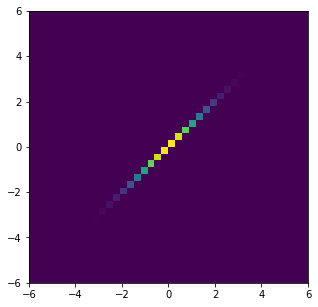

In [19]:
fig,ax = plt.subplots( ndim, ndim, figsize=(ndim*5, ndim*5))

hmin=-6
hmax=6
hbins=40

for i in range(ndim) :
    for j in range(ndim) :
        if j < i : continue
        if ndim > 1 :
            thisax = ax[i][j]
        else :
            thisax = ax
            
        thisax.hist2d( train_pts[:,i], train_pts[:,j], bins=[hbins,hbins], range=([hmin,hmax],[hmin,hmax]))



plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

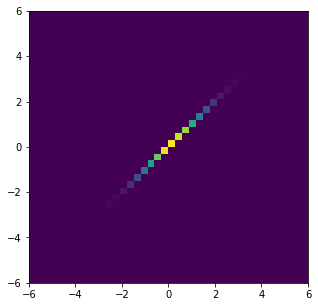

In [20]:
fig,ax = plt.subplots( ndim, ndim, figsize=(ndim*5, ndim*5))

hmin=-6
hmax=6
hbins=40

for i in range(ndim) :
    for j in range(ndim) :
        if j < i : continue
        if ndim > 1 :
            thisax = ax[i][j]
        else :
            thisax = ax
        thisax.hist2d( true_pts[:,i], true_pts[:,j], bins=[hbins,hbins], range=([hmin,hmax],[hmin,hmax]))



plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

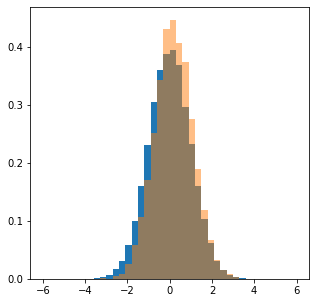

In [21]:
fig,ax = plt.subplots( 1, ndim, figsize=(ndim*5,5))

hmin=-6
hmax=6
hbins=40


for i in range(ndim) :
        k = i*3 + j
        if ndim > 1 :
            thisax = ax[i]
        else :
            thisax = ax
        thisax.hist( train_pts[:,i],bins=hbins, range=[hmin,hmax], density=True )
        thisax.hist( true_pts[:,i],bins=hbins, range=[hmin,hmax], density=True, alpha=0.5 )
    
plt.show

### Calculate true weights analytically and compare with unfolding output weights.

In [22]:
train_pts_minus_train_mu = train_pts - train_mu
print(train_pts_minus_train_mu)

[[ 1.62434536]
 [-0.61175641]
 [-0.52817175]
 ...
 [ 0.08122531]
 [ 0.34404618]
 [-0.74755625]]


In [23]:
train_pts_minus_true_mu = train_pts - true_mu
print(train_pts_minus_true_mu)

[[ 1.42434536]
 [-0.81175641]
 [-0.72817175]
 ...
 [-0.11877469]
 [ 0.14404618]
 [-0.94755625]]


In [24]:
true_cov_inv_times_v = np.tensordot( true_cov_inv, train_pts_minus_true_mu.T, axes=(1,0) )

In [25]:
v_times_true_cov_inv_times_v =  np.sum( train_pts_minus_true_mu.T * true_cov_inv_times_v, axis=0)

In [26]:
train_cov_inv_times_v = np.tensordot( train_cov_inv, train_pts_minus_train_mu.T, axes=(1,0) )

In [27]:
v_times_train_cov_inv_times_v =  np.sum( train_pts_minus_train_mu.T * train_cov_inv_times_v, axis=0)

In [28]:
exp_v_times_train_cov_inv_times_v = np.exp( -0.5 * v_times_train_cov_inv_times_v )
exp_v_times_true_cov_inv_times_v  = np.exp( -0.5 * v_times_true_cov_inv_times_v  )

In [29]:
true_cov_det = np.linalg.det( true_cov )
train_cov_det = np.linalg.det( train_cov )

In [30]:
norm2_true = np.power( 3.14159265, ndim) * true_cov_det
print("\n norm2_true : %f\n" % norm2_true )


 norm2_true : 2.544690



In [31]:
norm2_train = np.power( 3.14159265, ndim) * train_cov_det
print("\n norm2_train : %f\n" % norm2_train )


 norm2_train : 3.141593



In [32]:
pdf_train = exp_v_times_train_cov_inv_times_v / np.sqrt(norm2_train)
print(pdf_train)

[0.15082819 0.46790598 0.49073665 ... 0.56233152 0.53176755 0.42665263]


In [33]:
pdf_true = exp_v_times_true_cov_inv_times_v / np.sqrt(norm2_true)
print(pdf_true)

[0.17918702 0.4173781  0.45189319 ... 0.62144199 0.61889934 0.36014781]


In [34]:
pdf_ratio = pdf_true / pdf_train

In [35]:
sample_sf = (1.*len(true_pts))/(1.*len(train_pts))
print('\n sample_sf = %f' % sample_sf )


 sample_sf = 0.100000


In [36]:
calc_weight = pdf_ratio

In [37]:
calc_weight_scaled = sample_sf * pdf_ratio

## Set up NN model for OmniFold

In [38]:

import tensorflow.keras.backend as K


def weighted_binary_crossentropy(y_true, y_pred):
    weights = tf.gather(y_true, [1], axis=1) # event weights
    y_true = tf.gather(y_true, [0], axis=1) # actual y_true for loss

    # Clip the prediction value to prevent NaN's and Inf's
    epsilon = K.epsilon()
    y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

    t_loss = -weights * ((y_true) * K.log(y_pred) +
                         (1 - y_true) * K.log(1 - y_pred))

    return K.mean(t_loss)

In [39]:





reg_setval_zero = 0.0


model_step1 = Sequential()

model_step1.add( Dense(units_per_layer, input_dim=ndim, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
if use_batch_norm : model_step1.add( BatchNormalization() )
model_step1.add( Dropout(dropout_setval) )

if number_of_layers > 1 :
    model_step1.add( Dense(units_per_layer, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval), 
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
    if use_batch_norm : model_step1.add( BatchNormalization() )
    model_step1.add( Dropout(dropout_setval) )

if number_of_layers > 2 :
    model_step1.add( Dense(units_per_layer, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
    if use_batch_norm : model_step1.add( BatchNormalization() )
    model_step1.add( Dropout(dropout_setval) )

model_step1.add( Dense(1, activation='sigmoid') )





model_step2 = Sequential()

model_step2.add( Dense(units_per_layer, input_dim=ndim, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval), 
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
if use_batch_norm : model_step2.add( BatchNormalization() )
model_step2.add( Dropout(dropout_setval) )

if number_of_layers > 1 :
    model_step2.add( Dense(units_per_layer, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
    if use_batch_norm : model_step2.add( BatchNormalization() )
    model_step2.add( Dropout(dropout_setval) )

if number_of_layers > 2 :
    model_step2.add( Dense(units_per_layer, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
    if use_batch_norm : model_step2.add( BatchNormalization() )
    model_step2.add( Dropout(dropout_setval) )

model_step2.add( Dense(1, activation='sigmoid') )


#----








opt_step1 = tf.keras.optimizers.Adam( learning_rate=learning_rate_setval )
##########opt_step2 = tf.keras.optimizers.Adam( learning_rate=(0.04*learning_rate_setval) )  # owen: use lower learning rate in step 2
opt_step2 = tf.keras.optimizers.Adam( learning_rate=learning_rate_setval )



model_step1.compile(loss=weighted_binary_crossentropy,
                      optimizer=opt_step1,
                      metrics=['accuracy'])

model_step2.compile(loss=weighted_binary_crossentropy,
                      optimizer=opt_step2,
                      metrics=['accuracy'])

print('\n\n ------ model_step1:')
model_step1.summary()

print('\n\n ------ model_step2:')
model_step2.summary()

/usr/lib/python3/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1739190393.164993 2640954 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739190393.209353 2640954 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739190393.209653 2640954 cuda_executor.cc:1015] successful NUMA n



 ------ model_step1:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,251 (20.51 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,251 (20.51 KB)

 Trainable params: 5,251 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

## Package the training data for OmniFold

In [40]:
train_both = np.stack([train_pts, train_det_pts], axis=1)

## Run OmniFold

In [41]:
def reweight(events,model,batch_size=10000):
    f = model.predict(events, batch_size=batch_size)
    epsilon = K.epsilon()
    f = K.clip( f, epsilon, 1. - epsilon )  #owen: protect against divide by zero.
    weights = f / (1. - f)
    return np.squeeze(np.nan_to_num(weights))


In [42]:
# Binary crossentropy for classifying two samples with weights
# Weights are "hidden" by zipping in y_true (the labels)

def weighted_binary_crossentropy(y_true, y_pred):
    weights = tf.gather(y_true, [1], axis=1) # event weights
    y_true = tf.gather(y_true, [0], axis=1) # actual y_true for loss

    # Clip the prediction value to prevent NaN's and Inf's
    epsilon = K.epsilon()
    y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

    t_loss = -weights * ((y_true) * K.log(y_pred) +
                         (1 - y_true) * K.log(1 - y_pred))

    return K.mean(t_loss)

## Set the internal omnifold.py variables from the function arguments

In [43]:
theta0 = train_both
theta_unknown_S = true_det_pts
iterations = of_niter
verbose = True


## Here's the function code

In [44]:
weights = np.empty(shape=(iterations, 2, len(theta0)))
# shape = (iteration, step, event)
push_weights_for_output = np.empty(shape=(iterations, len(theta0)))

theta0_G = theta0[:,0]
theta0_S = theta0[:,1]

labels0 = np.zeros(len(theta0))
labels_unknown = np.ones(len(theta_unknown_S))
labels_unknown_step2 = np.ones(len(theta0_G))

pretrain_xvals_1 = np.concatenate((theta0_S, theta0_S))
pretrain_yvals_1 = np.concatenate( (np.ones(len(theta0_S)), np.zeros(len(theta0_S))) )
xvals_1 = np.concatenate((theta0_S, theta_unknown_S))
yvals_1 = np.concatenate((labels0, labels_unknown))

pretrain_xvals_2 = np.concatenate((theta0_G, theta0_G))
pretrain_yvals_2 = np.concatenate( (np.ones(len(theta0_G)), np.zeros(len(theta0_G))) )
xvals_2 = np.concatenate((theta0_G, theta0_G))
yvals_2 = np.concatenate((labels0, labels_unknown_step2))

if verbose :
    print("\n\n")
    print("  ======== omnifold9c\n\n")
    print("  shape of theta0_S : %s" % str(np.shape(theta0_S)) ) ;
    print("  shape of theta_unknown_S : %s" % str(np.shape(theta_unknown_S)) ) ;
    print("  shape of xvals_1 :  %s" % str(np.shape( xvals_1 )) ) ;
    print("\n\n")
    print("  shape of labels0 : %s" % str(np.shape(labels0)) ) ;
    print("  shape of labels_unknown : %s" % str(np.shape(labels_unknown)) ) ;
    print("  shape of yvals_1 :  %s" % str(np.shape( yvals_1 )) ) ;
    print("\n\n")
    print("  shape of theta0_G : %s" % str(np.shape(theta0_G)) ) ;
    print("  shape of xvals_2 :  %s" % str(np.shape( xvals_2 )) ) ;
    print("  shape of yvals_2 :  %s" % str(np.shape( yvals_2 )) ) ;
    print("\n batch size setval  %d" % batch_size_setval )
    print(" epochs setval  %d" % epochs_setval )
    print("\n\n")

# initial iterative weights are ones
weights_pull = np.ones(len(theta0_S))
weights_push = np.ones(len(theta0_S))


# owen: rescale the MC weights to balance the two categories for step 1 in first iteration.
mc_weight_sf = (1.*len(theta_unknown_S))/(1.*len(theta0_S))


return_dict = {}




  ======== omnifold9c


  shape of theta0_S : (100000, 1)
  shape of theta_unknown_S : (10000, 1)
  shape of xvals_1 :  (110000, 1)



  shape of labels0 : (100000,)
  shape of labels_unknown : (10000,)
  shape of yvals_1 :  (110000,)



  shape of theta0_G : (100000, 1)
  shape of xvals_2 :  (200000, 1)
  shape of yvals_2 :  (200000,)

 batch size setval  10000
 epochs setval  50





In [45]:
#-- new code

print('\n\n Saving model weights for reinitialization\n\n')

initial_s1_weights_fname = '%s/initial-model-weights-s1.weights.h5' % output_dir
print(' step 1 :  %s ' % initial_s1_weights_fname )
model_step1.save_weights( initial_s1_weights_fname )

initial_s2_weights_fname = '%s/initial-model-weights-s2.weights.h5' % output_dir
print(' step 1 :  %s ' % initial_s2_weights_fname )
model_step2.save_weights( initial_s2_weights_fname )

print('\n\n')




 Saving model weights for reinitialization


 step 1 :  bootstrap-all-in-one-inspect-of-1d-8a/initial-model-weights-s1.weights.h5 
 step 1 :  bootstrap-all-in-one-inspect-of-1d-8a/initial-model-weights-s2.weights.h5 





In [46]:
model_step1.layers

[<Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>,
 <Dropout name=dropout_1, built=True>,
 <Dense name=dense_2, built=True>,
 <Dropout name=dropout_2, built=True>,
 <Dense name=dense_3, built=True>]

In [47]:
for li in range(len(model_step1.layers)) :
    print( ' \n layer index %2d : name = %s' % (li, model_step1.layers[li].name) )
    if 'dropout' in model_step1.layers[li].name : continue
    for gwi in range( len( model_step1.layers[li].get_weights() )) :
        print( ' %3d, %3d : shape %s' % (li, gwi, str(model_step1.layers[li].get_weights()[gwi].shape)) )
        print( ' %3d, %3d : range %5.3f to %5.3f' % (li, gwi, 
                                                     np.min(model_step1.layers[li].get_weights()[gwi]),
                                                     np.max(model_step1.layers[li].get_weights()[gwi]),
                                                    ))
        #print( ' %3d : %s' % (gwi, str(model_step1.layers[li].get_weights()[gwi])) )
    

 
 layer index  0 : name = dense
   0,   0 : shape (1, 50)
   0,   0 : range -0.332 to 0.317
   0,   1 : shape (50,)
   0,   1 : range 0.000 to 0.000
 
 layer index  1 : name = dropout
 
 layer index  2 : name = dense_1
   2,   0 : shape (50, 50)
   2,   0 : range -0.244 to 0.245
   2,   1 : shape (50,)
   2,   1 : range 0.000 to 0.000
 
 layer index  3 : name = dropout_1
 
 layer index  4 : name = dense_2
   4,   0 : shape (50, 50)
   4,   0 : range -0.245 to 0.245
   4,   1 : shape (50,)
   4,   1 : range 0.000 to 0.000
 
 layer index  5 : name = dropout_2
 
 layer index  6 : name = dense_3
   6,   0 : shape (50, 1)
   6,   0 : range -0.338 to 0.312
   6,   1 : shape (1,)
   6,   1 : range 0.000 to 0.000


## The main loop over OmniFold iterations is here

In [48]:
%%time



for i in range(iterations):

    if (verbose>0):
        print("\nITERATION: {}\n".format(i + 1))
        pass

    # STEP 1: classify Sim. (which is reweighted by weights_push) to Data
    # weights reweighted Sim. --> Data

    if (verbose>0):
        print("   -- ITERATION %d  STEP 1\n" % (i+1) )
        pass

    print(" weights_push at the beginning")
    print( weights_push )


    #--- new 2025-02-06 : reinitialize weights every time.
    print('    reloading initial model weights')
    model_step1.load_weights( initial_s1_weights_fname )
    model_step2.load_weights( initial_s2_weights_fname )

 # owen: put the scaling here so that weights_push keeps its meaning (order 1).
    weights_1 = np.concatenate((mc_weight_sf * weights_push, np.ones(len(theta_unknown_S))))

    X_train_1, X_test_1, Y_train_1, Y_test_1, w_train_1, w_test_1 = train_test_split(xvals_1, yvals_1, weights_1)

    # zip ("hide") the weights with the labels
    Y_train_1 = np.stack((Y_train_1, w_train_1), axis=1)
    Y_test_1 = np.stack((Y_test_1, w_test_1), axis=1)
    if i > -1 :

            pretrain_weights_1 = np.concatenate( (np.ones(len(theta0_S)), np.ones(len(theta0_S))) )

            pt_X_train_1, pt_X_test_1, pt_Y_train_1, pt_Y_test_1, pt_w_train_1, pt_w_test_1 = train_test_split(pretrain_xvals_1, pretrain_yvals_1, pretrain_weights_1)

            pt_Y_train_1 = np.stack((pt_Y_train_1, pt_w_train_1), axis=1)
            pt_Y_test_1 = np.stack((pt_Y_test_1, pt_w_test_1), axis=1)

            if verbose>0 :
                    print("             running pre-training, distinguish from self.")

            model_step1.fit( pt_X_train_1, pt_Y_train_1, epochs=5, batch_size=batch_size_setval, verbose=verbose )

            if verbose>0 :
                    print("             done pretraining.")

    this_epochs = epochs_setval
    if i == 0 : this_epochs = this_epochs*2


    train_history_step1 = model_step1.fit(X_train_1,
              Y_train_1,
              epochs=this_epochs,
              batch_size=batch_size_setval,
              validation_data=(X_test_1, Y_test_1),
              verbose=verbose )

    step1_output_weights = reweight(theta0_S,model_step1)

    weights_pull = weights_push * step1_output_weights

    weights[i, :1, :] = step1_output_weights

    return_dict["train-hist-step1-iter%d" % i] = train_history_step1
    
    return_dict['model_weights_step1_iter%d' % i] = np.copy( model_step1.layers[0].get_weights()[0] )

    return_dict['model_biases_step1_iter%d' % i] = np.copy( model_step1.layers[0].get_weights()[1] )


    # STEP 2: classify Gen. to reweighted Gen. (which is reweighted by weights_pull)
    # weights Gen. --> reweighted Gen.

    if (verbose>0):
        print("\n   -- ITERATION %d  STEP 2\n" % (i+1) )
        pass


    # ones for Gen. (not MC weights), actual weights for (reweighted) Gen.
    weights_2 = np.concatenate((   weights_push  , weights_pull))

    X_train_2, X_test_2, Y_train_2, Y_test_2, w_train_2, w_test_2 = train_test_split(xvals_2, yvals_2, weights_2)

    # zip ("hide") the weights with the labels
    Y_train_2 = np.stack((Y_train_2, w_train_2), axis=1)
    Y_test_2 = np.stack((Y_test_2, w_test_2), axis=1)

    if i > -1 :

            pretrain_weights_2 = np.concatenate( (np.ones(len(theta0_G)), np.ones(len(theta0_G))) )

            pt_X_train_2, pt_X_test_2, pt_Y_train_2, pt_Y_test_2, pt_w_train_2, pt_w_test_2 = train_test_split(pretrain_xvals_2, pretrain_yvals_2, pretrain_weights_2)

            pt_Y_train_2 = np.stack((pt_Y_train_2, pt_w_train_2), axis=1)
            pt_Y_test_2 = np.stack((pt_Y_test_2, pt_w_test_2), axis=1)

            if verbose>0 :
                    print("             running pre-training, distinguish from self.")

            model_step2.fit( pt_X_train_2, pt_Y_train_2, epochs=5, batch_size=batch_size_setval, verbose=verbose )

            if verbose>0 :
                    print("             done pretraining.")


    train_history_step2 = model_step2.fit(X_train_2,
              Y_train_2,
              epochs=this_epochs,
              batch_size=batch_size_setval,
              validation_data=(X_test_2, Y_test_2),
              verbose=verbose )

    return_dict["train-hist-step2-iter%d" % i] = train_history_step2
    
    return_dict['model_weights_step2_iter%d' % i] = np.copy( model_step2.layers[0].get_weights()[0] )

    return_dict['model_biases_step2_iter%d' % i] = np.copy( model_step2.layers[0].get_weights()[1] )


    step2_output_weights = reweight(theta0_G,model_step2)

    weights_push = step2_output_weights * weights_push

    push_weights_for_output[i] = weights_push

    weights[i, 1:2, :] = step2_output_weights

    if save_step2_model :
        model_output_dir = "%s/of-step2-iter%02d-model" % (output_dir, i)
        print("\n +++ Saving step 2, iteration %d model in %s" % (i, model_output_dir) )
        model_step2.save( "%s.keras" % model_output_dir )

return_dict["weights"] = weights

return_dict["push_weights"] = push_weights_for_output

return_dict["final_push_weights"] = weights_push




ITERATION: 1

   -- ITERATION 1  STEP 1

 weights_push at the beginning
[1. 1. 1. ... 1. 1. 1.]
    reloading initial model weights
             running pre-training, distinguish from self.
Epoch 1/5


I0000 00:00:1739190394.614513 2650550 service.cc:146] XLA service 0x7ea68c004eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1739190394.614559 2650550 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2025-02-10 04:26:34.664328: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-02-10 04:26:34.764959: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4377 - loss: 0.6944
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - accuracy: 0.6577 - loss: 0.6932
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - accuracy: 0.6821 - loss: 0.6931
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step - accuracy: 0.6223 - loss: 0.6931
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step - accuracy: 0.6671 - loss: 0.6931


I0000 00:00:1739190395.405997 2650550 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


             done pretraining.
Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step - accuracy: 0.1926 - loss: 0.1253 - val_accuracy: 0.2386 - val_loss: 0.1259
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2424 - loss: 0.1250 - val_accuracy: 0.2564 - val_loss: 0.1255
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2554 - loss: 0.1247 - val_accuracy: 0.2592 - val_loss: 0.1253
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2563 - loss: 0.1246 - val_accuracy: 0.2552 - val_loss: 0.1252
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2512 - loss: 0.1245 - val_accuracy: 0.2482 - val_loss: 0.1252
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2444 - loss: 0.1245 - val_accuracy: 0.2420 - val_loss: 0.1252
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2381 - loss: 0.1245 - val_accuracy: 0.2370 - val_loss: 0.1252
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2339 - loss: 0.1245 - val_acc

...

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2508 - loss: 0.6956 - val_accuracy: 0.2482 - val_loss: 0.6965
Epoch 40/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2507 - loss: 0.6956 - val_accuracy: 0.2483 - val_loss: 0.6965
Epoch 41/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2507 - loss: 0.6956 - val_accuracy: 0.2483 - val_loss: 0.6965
Epoch 42/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2507 - loss: 0.6956 - val_accuracy: 0.2482 - val_loss: 0.6965
Epoch 43/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2508 - loss: 0.6956 - val_accuracy: 0.2482 - val_loss: 0.6965
Epoch 44/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2508 - loss: 0.6956 - val_accuracy: 0.2481 - val_loss: 0.6965
Epoch 45/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2509 - loss: 0.6956 - val_accuracy: 0.2481 - val_loss: 0.6965
Epoch 46/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2508 - loss: 0.6956 - val_accuracy: 0.2482 - val_loss: 0.6

Epoch 34/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3887 - loss: 0.1258 - val_accuracy: 0.3852 - val_loss: 0.1257
Epoch 35/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3886 - loss: 0.1258 - val_accuracy: 0.3850 - val_loss: 0.1257
Epoch 36/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3883 - loss: 0.1258 - val_accuracy: 0.3849 - val_loss: 0.1257
Epoch 37/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3881 - loss: 0.1258 - val_accuracy: 0.3847 - val_loss: 0.1257
Epoch 38/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3880 - loss: 0.1258 - val_accuracy: 0.3846 - val_loss: 0.1257
Epoch 39/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3880 - loss: 0.1258 - val_accuracy: 0.3845 - val_loss: 0.1257
Epoch 40/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3879 - loss: 0.1258 - val_accuracy: 0.3844 - val_loss: 0.1257
Epoch 41/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3878 - loss: 0.1258 - val_accuracy: 0.3843 - val_loss: 0.1257


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2495 - loss: 0.6898 - val_accuracy: 0.2483 - val_loss: 0.6900
Epoch 31/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2494 - loss: 0.6898 - val_accuracy: 0.2483 - val_loss: 0.6900
Epoch 32/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2495 - loss: 0.6898 - val_accuracy: 0.2483 - val_loss: 0.6900
Epoch 33/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2495 - loss: 0.6898 - val_accuracy: 0.2483 - val_loss: 0.6900
Epoch 34/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2494 - loss: 0.6898 - val_accuracy: 0.2483 - val_loss: 0.6900
Epoch 35/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2495 - loss: 0.6898 - val_accuracy: 0.2483 - val_loss: 0.6900
Epoch 36/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2495 - loss: 0.6898 - val_accuracy: 0.2482 - val_loss: 0.6900
Epoch 37/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2494 - loss: 0.6898 - val_accuracy: 0.2482 - val_loss: 0.6

Epoch 25/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1511 - loss: 0.1255 - val_accuracy: 0.1504 - val_loss: 0.1257
Epoch 26/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1503 - loss: 0.1255 - val_accuracy: 0.1496 - val_loss: 0.1257
Epoch 27/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1499 - loss: 0.1255 - val_accuracy: 0.1487 - val_loss: 0.1257
Epoch 28/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1493 - loss: 0.1255 - val_accuracy: 0.1484 - val_loss: 0.1257
Epoch 29/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1487 - loss: 0.1255 - val_accuracy: 0.1477 - val_loss: 0.1257
Epoch 30/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1482 - loss: 0.1255 - val_accuracy: 0.1473 - val_loss: 0.1257
Epoch 31/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1480 - loss: 0.1255 - val_accuracy: 0.1470 - val_loss: 0.1257
Epoch 32/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1486 - loss: 0.1255 - val_accuracy: 0.1528 - val_loss: 0.1257


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2512 - loss: 0.6933 - val_accuracy: 0.2476 - val_loss: 0.6941
Epoch 22/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2512 - loss: 0.6933 - val_accuracy: 0.2475 - val_loss: 0.6941
Epoch 23/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2512 - loss: 0.6933 - val_accuracy: 0.2475 - val_loss: 0.6941
Epoch 24/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2512 - loss: 0.6933 - val_accuracy: 0.2475 - val_loss: 0.6941
Epoch 25/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2512 - loss: 0.6933 - val_accuracy: 0.2474 - val_loss: 0.6941
Epoch 26/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2512 - loss: 0.6933 - val_accuracy: 0.2474 - val_loss: 0.6941
Epoch 27/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2512 - loss: 0.6933 - val_accuracy: 0.2474 - val_loss: 0.6941
Epoch 28/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2512 - loss: 0.6933 - val_accuracy: 0.2474 - val_loss: 0.6

In [49]:
of_return_dict = return_dict

In [50]:
of_return_dict.keys()

dict_keys(['train-hist-step1-iter0', 'model_weights_step1_iter0', 'model_biases_step1_iter0', 'train-hist-step2-iter0', 'model_weights_step2_iter0', 'model_biases_step2_iter0', 'train-hist-step1-iter1', 'model_weights_step1_iter1', 'model_biases_step1_iter1', 'train-hist-step2-iter1', 'model_weights_step2_iter1', 'model_biases_step2_iter1', 'train-hist-step1-iter2', 'model_weights_step1_iter2', 'model_biases_step1_iter2', 'train-hist-step2-iter2', 'model_weights_step2_iter2', 'model_biases_step2_iter2', 'train-hist-step1-iter3', 'model_weights_step1_iter3', 'model_biases_step1_iter3', 'train-hist-step2-iter3', 'model_weights_step2_iter3', 'model_biases_step2_iter3', 'train-hist-step1-iter4', 'model_weights_step1_iter4', 'model_biases_step1_iter4', 'train-hist-step2-iter4', 'model_weights_step2_iter4', 'model_biases_step2_iter4', 'weights', 'push_weights', 'final_push_weights'])

In [51]:
of_weights = of_return_dict["weights"]

mc_weight_sf = (1.*len(true_det_pts))/(1.*len(train_both))

push_weights = of_return_dict["push_weights"]
push_weights_scaled = np.copy( push_weights )
push_weights_scaled = mc_weight_sf * push_weights

final_push_weights = of_return_dict["final_push_weights"]
final_push_weights_scaled = np.copy(final_push_weights)
final_push_weights_scaled = mc_weight_sf * final_push_weights

with open( '%s/omnifold-output-weights.npy' % output_dir, 'wb') as f :
    np.save(f, final_push_weights_scaled)

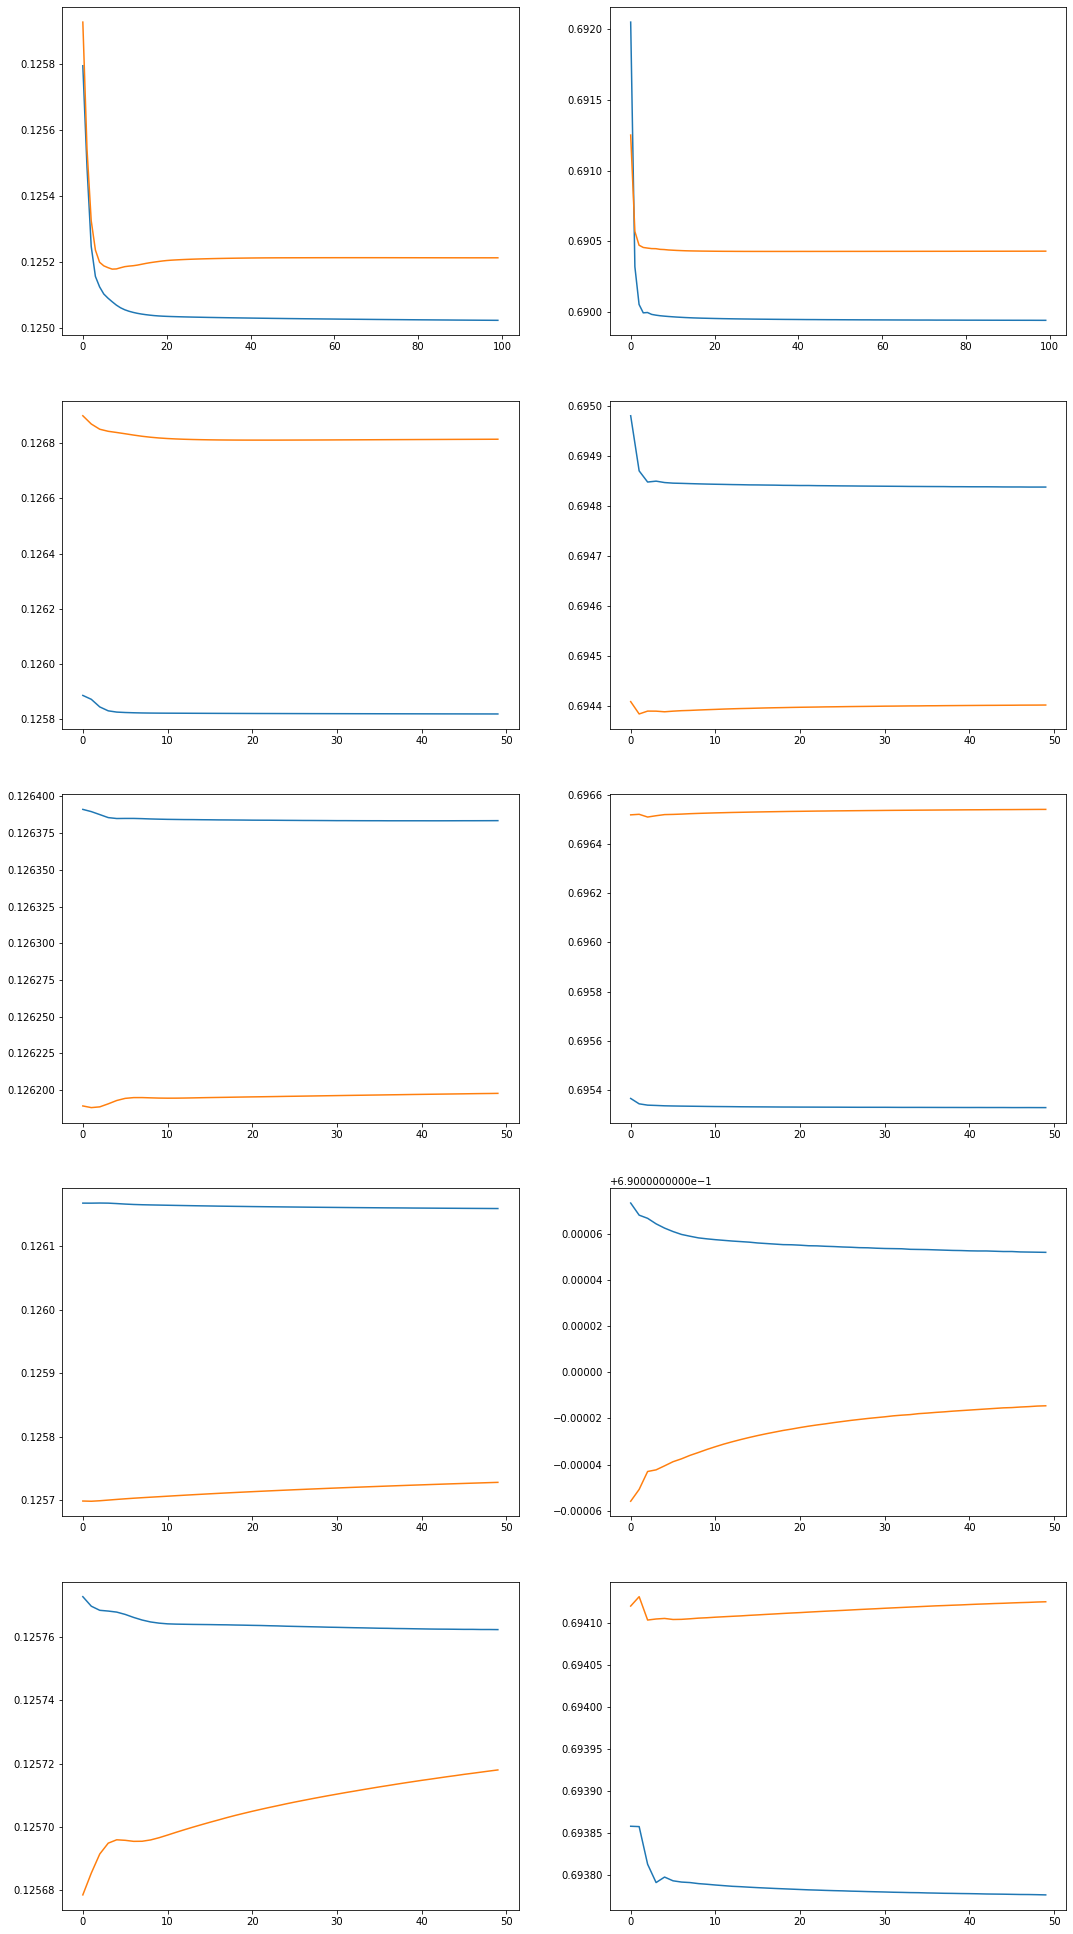

In [52]:
fig,ax = plt.subplots( of_niter, 2, figsize=(18,7*of_niter))

for ofi in range(0,of_niter) :
    
    ax[ofi][0].plot( of_return_dict['train-hist-step1-iter%d' % ofi].history['loss']  )
    ax[ofi][0].plot( of_return_dict['train-hist-step1-iter%d' % ofi].history['val_loss']  )

    ax[ofi][1].plot( of_return_dict['train-hist-step2-iter%d' % ofi].history['loss']  )
    ax[ofi][1].plot( of_return_dict['train-hist-step2-iter%d' % ofi].history['val_loss']  )
    



<function matplotlib.pyplot.show(close=None, block=None)>

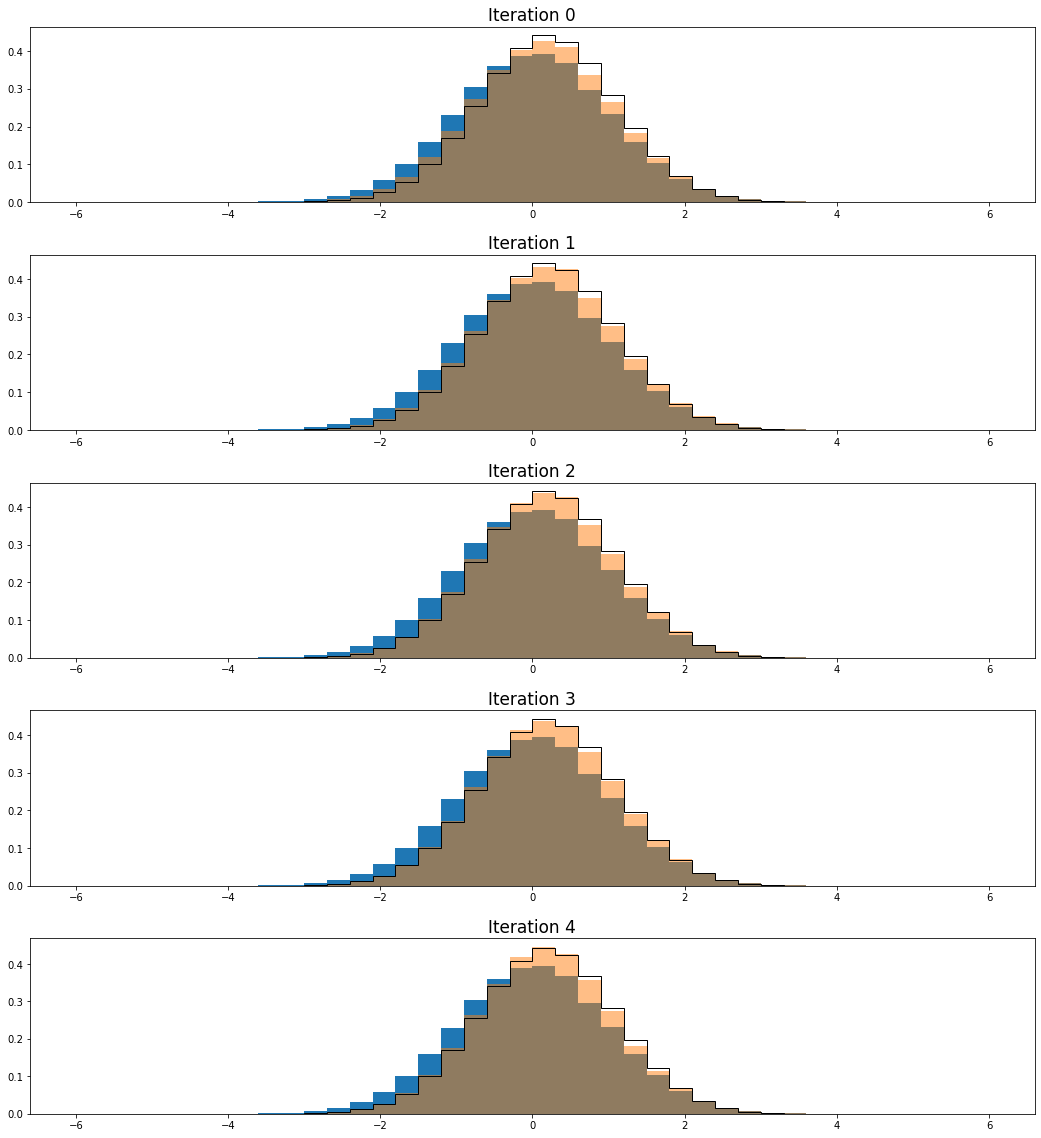

In [53]:


fig,ax = plt.subplots( of_niter, ndim, figsize=(18,4*of_niter))

hmin=-6
hmax=6
hbins=40

hist_data_mc_ofweighted = np.zeros( shape=(of_niter,ndim,hbins))
hist_data_truth         = np.zeros( shape=(of_niter,ndim,hbins))

lfontsize = 17

plt.subplots_adjust( hspace=0.30)
plt.subplots_adjust( wspace=0.25)

do_renorm = True


for ofi in range(0,of_niter) :

    if do_renorm :
        
        for di in range(ndim) :
            
            if ndim > 1 :
                thisax = ax[ofi][di]
            else :
                thisax = ax[ofi]
            
            thisax.hist( train_pts[:,di], bins=hbins, density=True, range=[hmin,hmax], label='train particle' )
            hist_data_mc_ofweighted[ofi,di],_,_ = thisax.hist( train_pts[:,di], weights=push_weights[ofi], bins=hbins, density=True, range=[hmin,hmax], label='OF weighted particle', alpha=0.5 )            
            hist_data_truth[ofi,di],_,_ =         thisax.hist( true_pts10x[:,di], weights=true_pts10x_weights, bins=hbins, density=True, range=[hmin,hmax], label='true particle', histtype='step', color='black' )

    else :
        
        for di in range(ndim) :

            if ndim > 1 :
                thisax = ax[ofi][di]
            else :
                thisax = ax[ofi]
                
            hist_data_mc_ofweighted[ofi,di],_,_ = thisax.hist( train_pts[:,di], weights=push_weights_scaled[ofi], bins=hbins, range=[hmin,hmax], label='OF weighted particle', alpha=0.5 )            
            hist_data_truth[ofi,di],_,_ =         thisax.hist( true_pts10x[:,di], weights=true_pts10x_weights, bins=hbins, range=[hmin,hmax], label='true particle', histtype='step', color='black' )
        

    
    #ax[ofi][0].legend(loc='best', fontsize=13)
    #ax[ofi][1].legend(loc='best', fontsize=13)
    
    
#    ax[ofi][0].set_xlabel('Feature 0', fontsize=lfontsize )
    
#    ax[ofi][1].set_xlabel('Feature 1', fontsize=lfontsize )
 
    if ndim > 1 :
        thisax = ax[ofi][0]
    else :
        thisax = ax[ofi]
        
    thisax.set_title('Iteration %d' % ofi, fontsize=lfontsize )



plt.show

In [54]:
hist_data_diff = hist_data_mc_ofweighted - hist_data_truth
hist_data_diff2 = hist_data_diff * hist_data_diff

hist_data_sum_diff2 = np.zeros( shape=(of_niter,ndim))

for ofi in range( of_niter ) :
    for di in range( ndim ) :
        hist_data_sum_diff2[ofi,di] = np.sum( hist_data_diff2[ofi,di])


<function matplotlib.pyplot.show(close=None, block=None)>

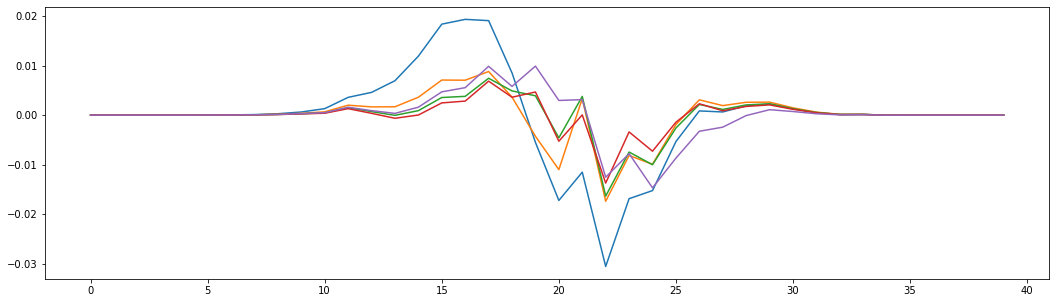

In [55]:
fig,ax = plt.subplots( 1, ndim, figsize=(18,5))

for ofi in range(of_niter) :
    for di in range( ndim ) :
        if ndim > 1 :
            thisax = ax[di]
        else :
            thisax = ax
        thisax.plot(hist_data_diff[ofi,di])

    
plt.show   

<function matplotlib.pyplot.show(close=None, block=None)>

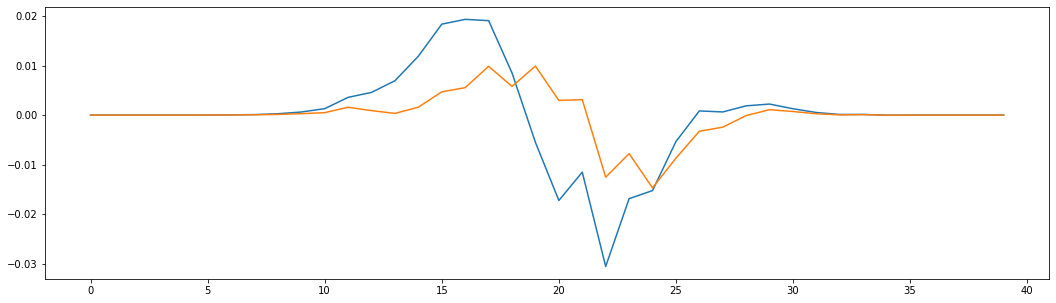

In [56]:
fig,ax = plt.subplots( 1, ndim, figsize=(18,5))

ofi = 0
for di in range( ndim ) :
    if ndim > 1 :
        thisax = ax[di]
    else :
        thisax = ax
    thisax.plot(hist_data_diff[ofi,di])

ofi = of_niter-1
for di in range( ndim ) :
    if ndim > 1 :
        thisax = ax[di]
    else :
        thisax = ax
    thisax.plot(hist_data_diff[ofi,di])
    
plt.show  

<function matplotlib.pyplot.show(close=None, block=None)>

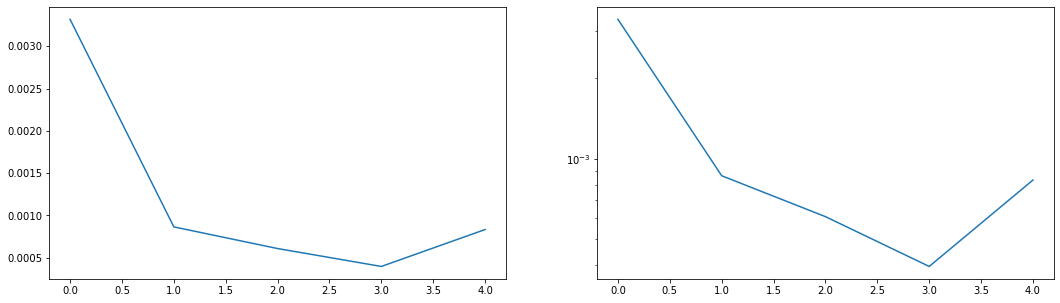

In [57]:
fig,ax = plt.subplots( 1, 2, figsize=(18,5))
ax[0].plot( hist_data_sum_diff2)
ax[1].plot( hist_data_sum_diff2)
ax[1].set_yscale('log')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

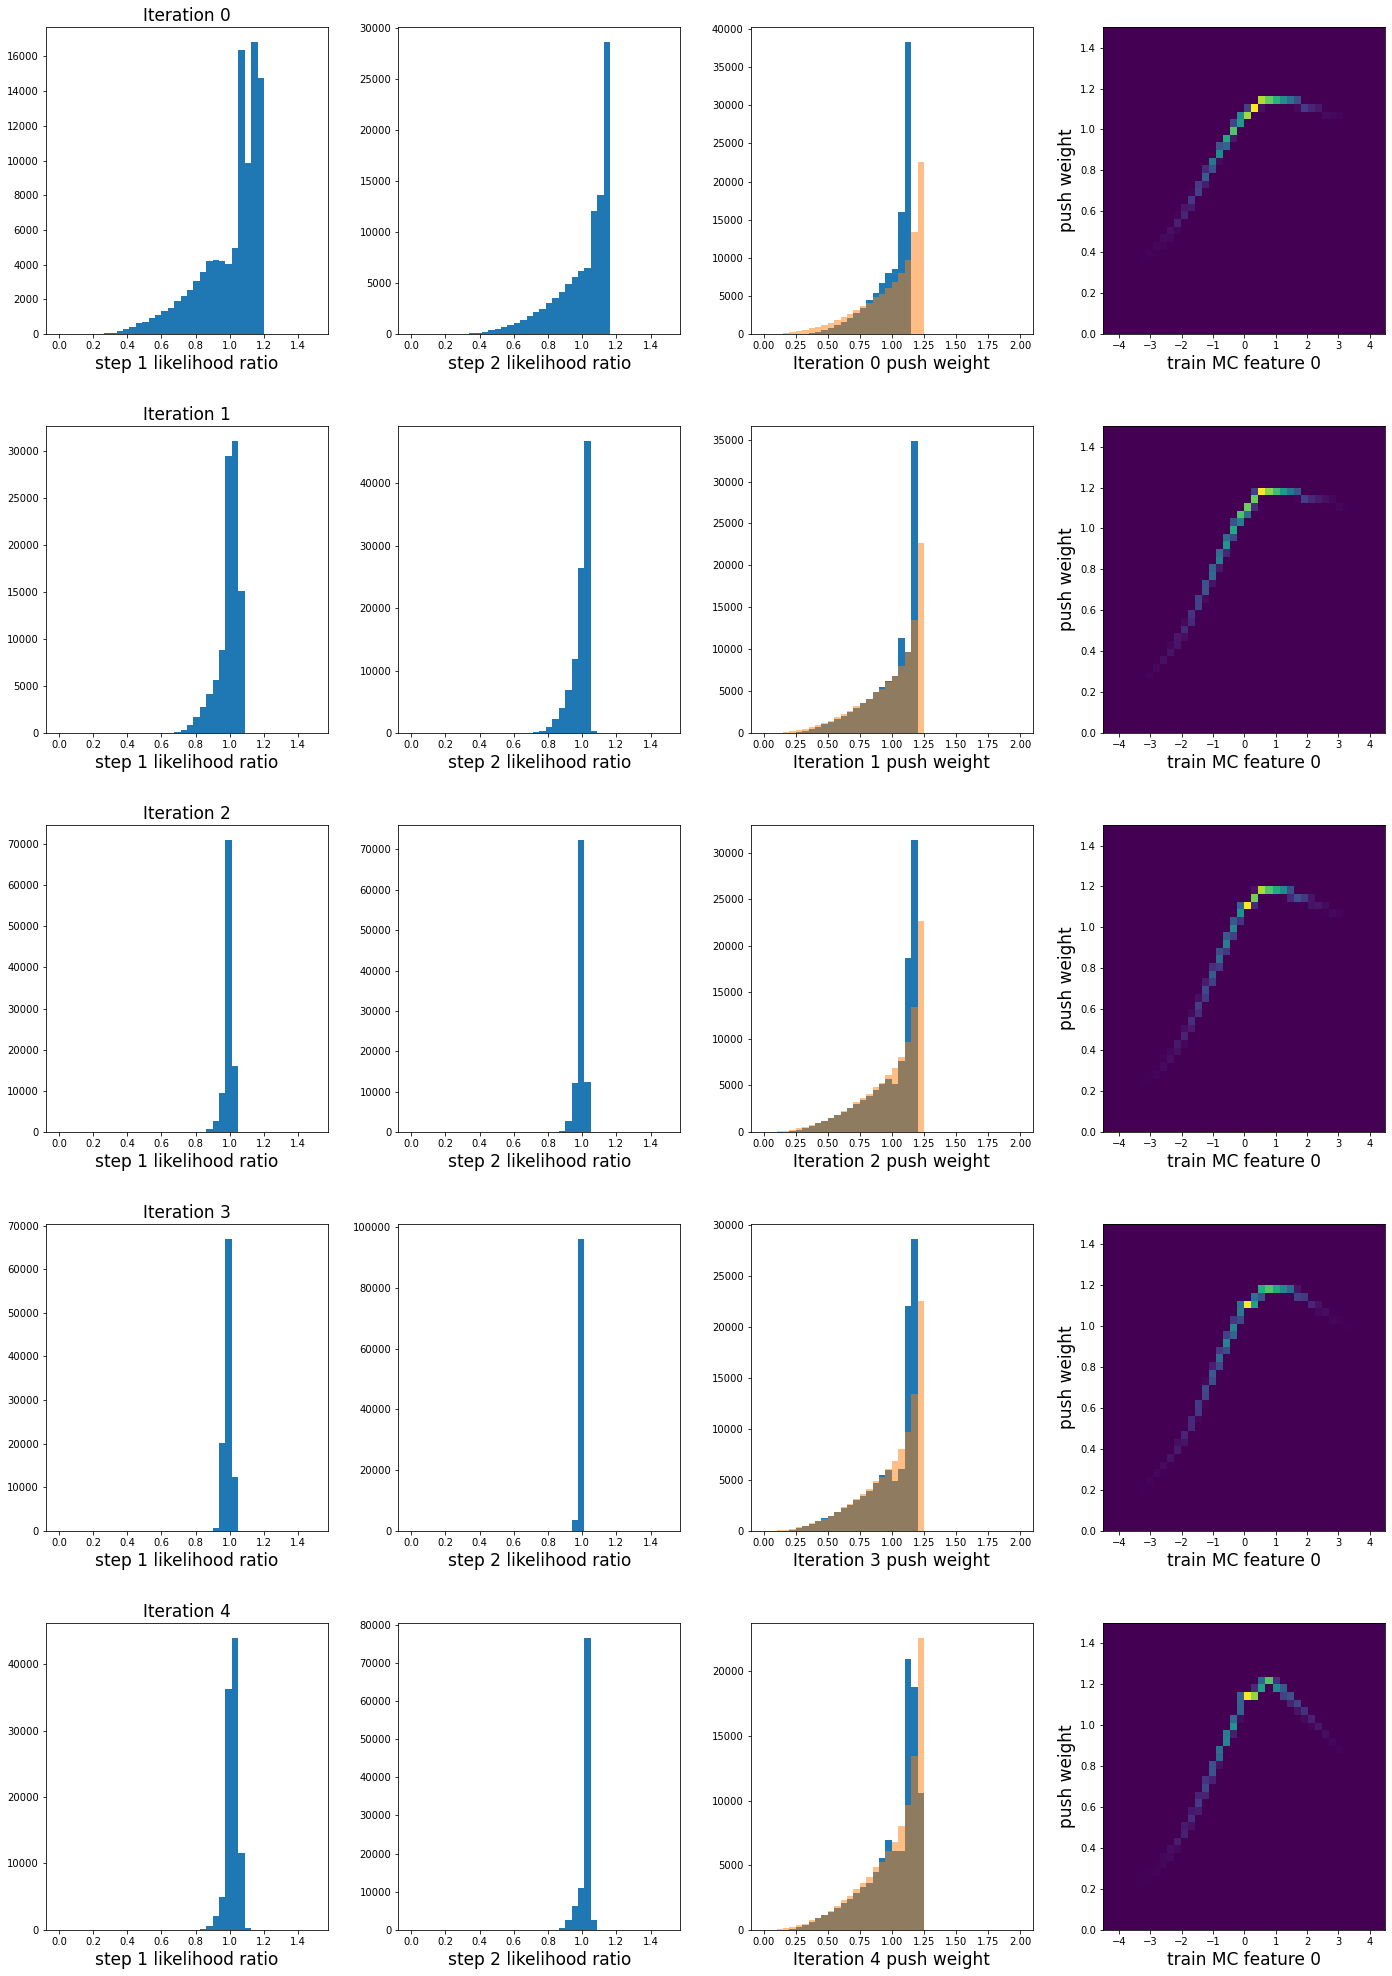

In [58]:
fig,ax = plt.subplots( of_niter, 4, figsize=(24,7*of_niter))

hmin=-6
hmax=6
hbins=40

lfontsize = 17

plt.subplots_adjust( hspace=0.30)
plt.subplots_adjust( wspace=0.25)

for ofi in range(0,of_niter) :

    ax[ofi][0].hist( of_weights[ofi,0,:], bins=hbins, range=[0.,1.5] )
    
    ax[ofi][1].hist( of_weights[ofi,1,:], bins=hbins, range=[0.,1.5] )
    
    ax[ofi][2].hist( push_weights[ofi,:], bins=hbins, range=[0.,2.0] )
    ax[ofi][2].hist( calc_weight, bins=hbins, range=[0.,2.0], alpha=0.5 )
    
    
    #ax[ofi][3].hist2d( of_weights[ofi,0,:], of_weights[ofi,1,:], bins=[hbins,hbins] )

    ax[ofi][3].hist2d( train_pts[:,0], push_weights[ofi,:], 
                      bins=[hbins,hbins], range=([-4.5,4.5],[0.,1.5]) )
    
    
    ax[ofi][0].set_xlabel( 'step 1 likelihood ratio', fontsize=lfontsize )
    
    ax[ofi][1].set_xlabel( 'step 2 likelihood ratio', fontsize=lfontsize )
    
    #ax[ofi][3].set_xlabel( 'step 1 likelihood ratio', fontsize=lfontsize )
    #ax[ofi][3].set_ylabel( 'step 2 likelihood ratio', fontsize=lfontsize )
    
    
    ax[ofi][3].set_xlabel( 'train MC feature 0' , fontsize=lfontsize )
    ax[ofi][3].set_ylabel( 'push weight' , fontsize=lfontsize )
    
    
    
    ax[ofi][2].set_xlabel( 'Iteration %d push weight' % ofi, fontsize=lfontsize )
    
    ax[ofi][0].set_title('Iteration %d' % ofi, fontsize=lfontsize )
    
    
    
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

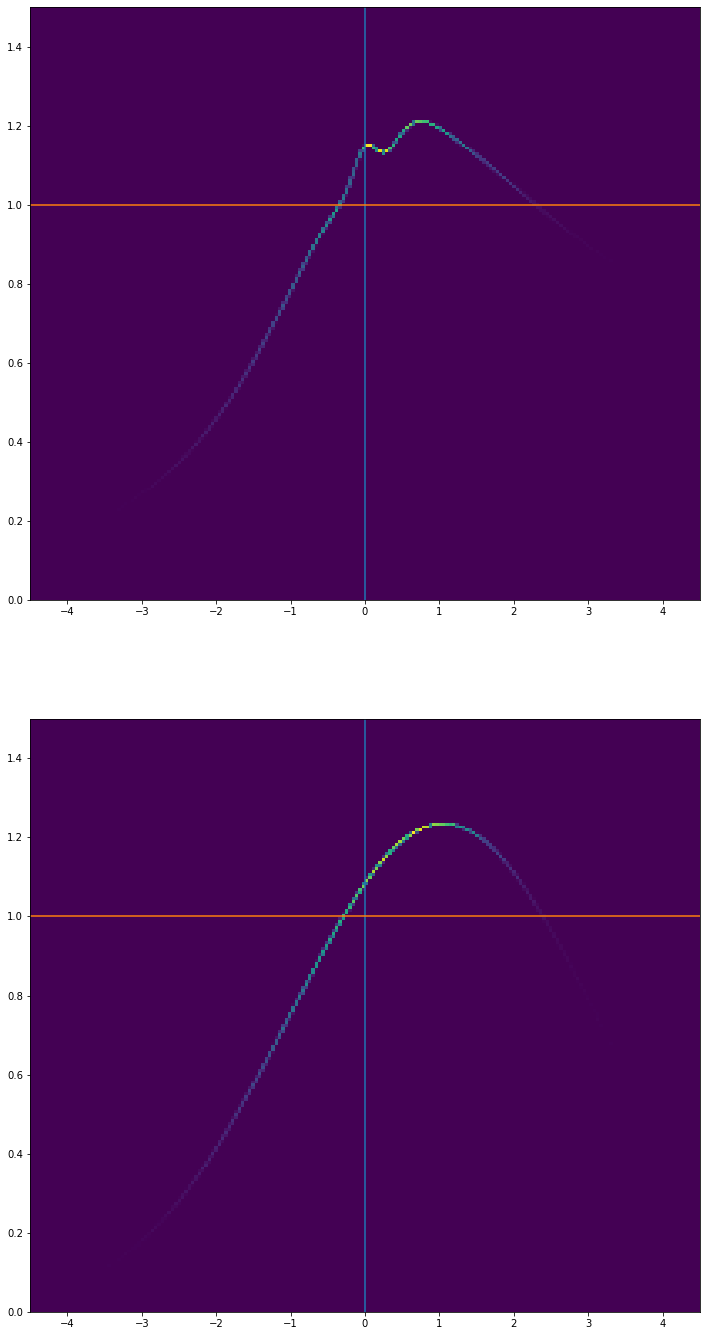

In [59]:
fig,ax = plt.subplots( 2, 1, figsize=(12,2*12))

hbins=200

hpw,_,_,_ = ax[0].hist2d( train_pts[:,0], push_weights[-1,:], 
                      bins=[hbins,hbins], range=([-4.5,4.5],[0.,1.5]) )

hcw,_,_,_ = ax[1].hist2d( train_pts[:,0], calc_weight, 
                      bins=[hbins,hbins], range=([-4.5,4.5],[0.,1.5]) )

ax[0].plot([0,0],[0,1.5])
ax[0].plot([-4.5,4.5],[1,1])

ax[1].plot([0,0],[0,1.5])
ax[1].plot([-4.5,4.5],[1,1])

plt.show

In [60]:
fpw = np.zeros( hpw.shape[0])

for bi0 in range(hpw.shape[0]) :
    esum = 0
    biesum = 0    
    for bi1 in range(hpw.shape[1]) :
        esum += hpw[bi0,bi1]
        biesum += bi1*hpw[bi0,bi1]
        #print(' %3d, %3d :  %8.0f    %8.0f  %8.0f' % (bi0, bi1, hpw[bi1,bi0], esum, biesum))
    wave = 0
    if esum > 0 :
        wave = biesum / esum
    fpw[bi0] = wave
    #print(' %3d : %8.3f' % (bi0, wave))

In [61]:
fcw = np.zeros( hcw.shape[0])

for bi0 in range(hcw.shape[0]) :
    esum = 0
    biesum = 0    
    for bi1 in range(hcw.shape[1]) :
        esum += hcw[bi0,bi1]
        biesum += bi1*hcw[bi0,bi1]
    wave = 0
    if esum > 0 :
        wave = biesum / esum
    fcw[bi0] = wave


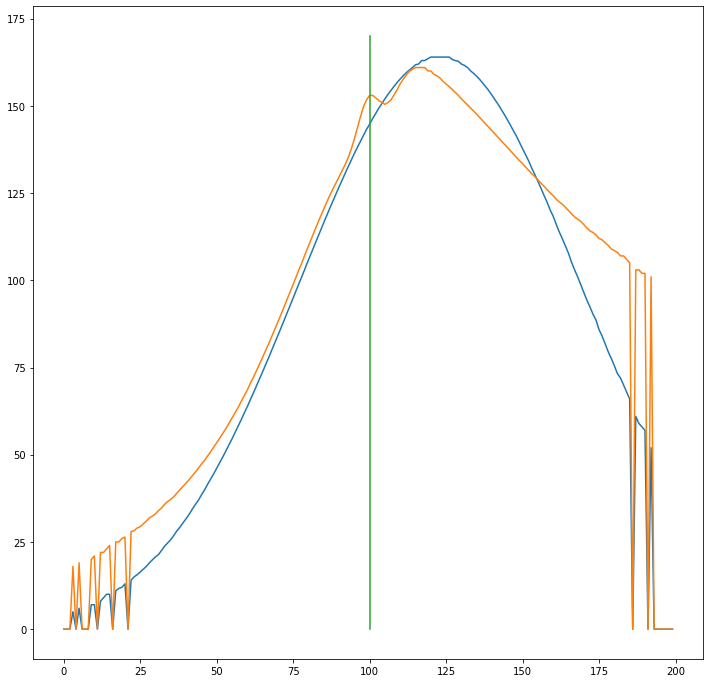

In [62]:
fig,ax = plt.subplots( 1, 1, figsize=(12,12))
ax.plot(fcw)
ax.plot(fpw)
ax.plot([100,100],[0,170])

<function matplotlib.pyplot.show(close=None, block=None)>

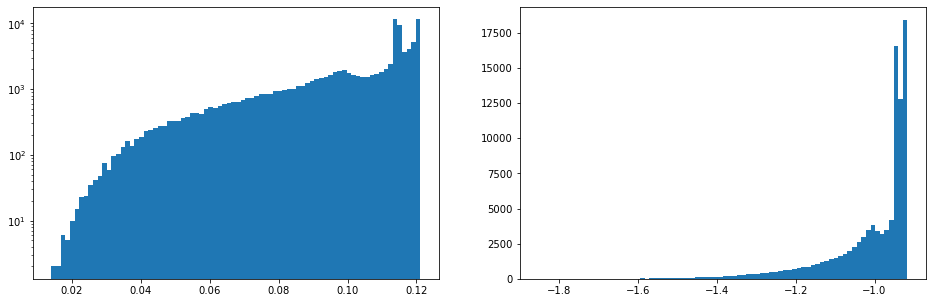

In [63]:
fig,ax = plt.subplots( 1, 2, figsize=(8*2,5))

hbins=80

ax[0].hist( final_push_weights_scaled, bins=hbins)
ax[0].set_yscale('log')

ax[1].hist( np.log10(final_push_weights_scaled), bins=hbins)

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

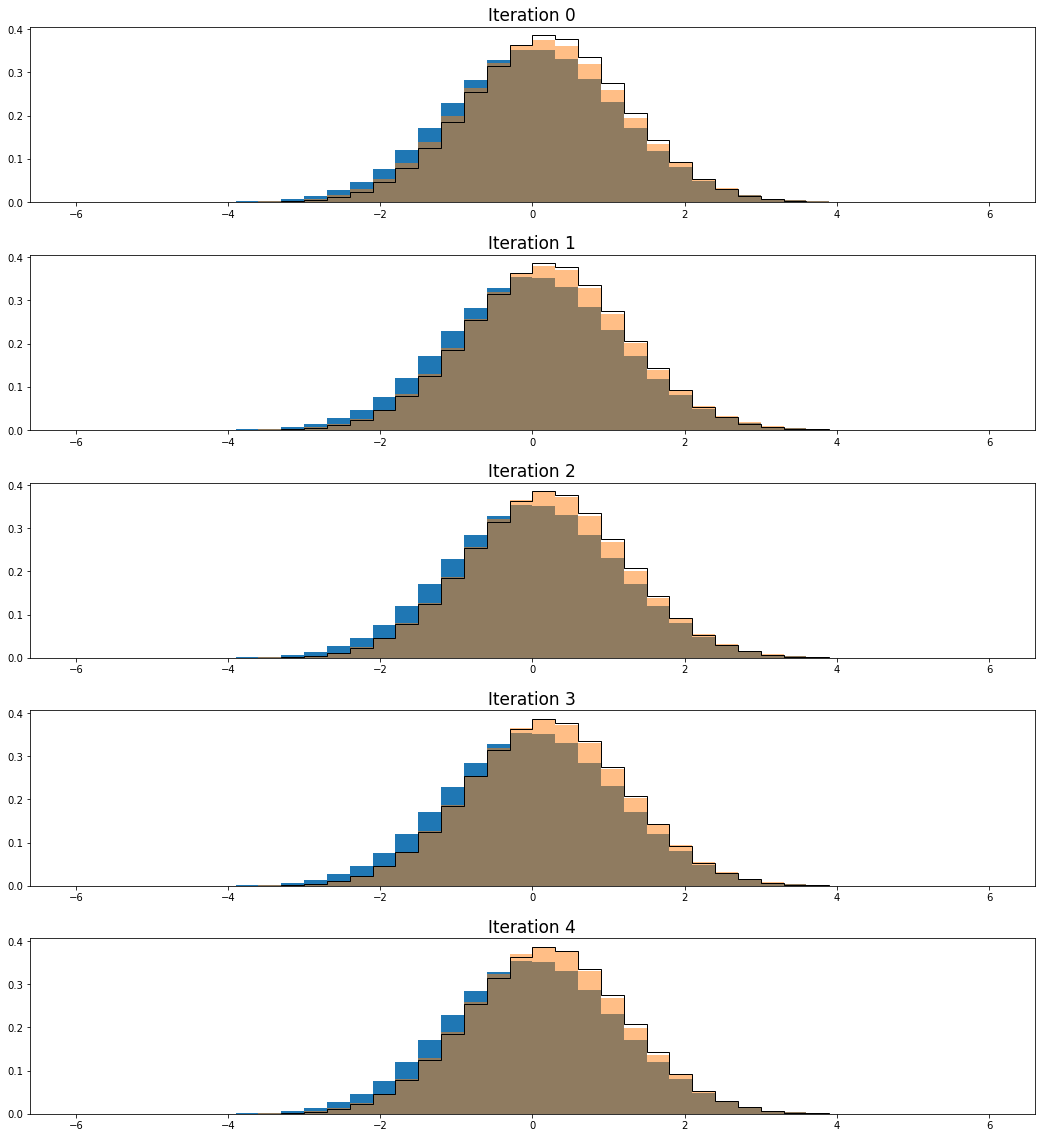

In [64]:

fig,ax = plt.subplots( of_niter, ndim, figsize=(18,4*of_niter))

hmin=-6
hmax=6
hbins=40

det_hist_data_mc_ofweighted = np.zeros( shape=(of_niter,ndim,hbins))
det_hist_data_truth         = np.zeros( shape=(of_niter,ndim,hbins))

lfontsize = 17

plt.subplots_adjust( hspace=0.30)
plt.subplots_adjust( wspace=0.25)

do_renorm = True


for ofi in range(0,of_niter) :

    if do_renorm :
        
        for di in range(ndim) :
            
            if ndim > 1 :
                thisax = ax[ofi][di]
            else :
                thisax = ax[ofi]
            
            thisax.hist( train_det_pts[:,di], bins=hbins, density=True, range=[hmin,hmax], label='train particle' )
            det_hist_data_mc_ofweighted[ofi,di],_,_ = thisax.hist( train_det_pts[:,di], weights=push_weights[ofi], bins=hbins, density=True, range=[hmin,hmax], label='OF weighted particle', alpha=0.5 )
            det_hist_data_truth[ofi,di],_,_ =         thisax.hist( true_det_pts10x[:,di], weights=true_pts10x_weights, bins=hbins, density=True, range=[hmin,hmax], label='true particle', histtype='step', color='black' )

    else :
        
        for di in range(ndim) :

            if ndim > 1 :
                thisax = ax[ofi][di]
            else :
                thisax = ax[ofi]
        
            det_hist_data_mc_ofweighted[ofi,di],_,_ = thisax.hist( train_det_pts[:,di], weights=push_weights_scaled[ofi], bins=hbins, range=[hmin,hmax], label='OF weighted particle', alpha=0.5 )
            det_hist_data_truth[ofi,di],_,_ =         thisax.hist( true_det_pts10x[:,di], weights=true_pts10x_weights, bins=hbins, range=[hmin,hmax], label='true particle', histtype='step', color='black' )
        

    
    #ax[ofi][0].legend(loc='best', fontsize=13)
    #ax[ofi][1].legend(loc='best', fontsize=13)
    
    
#    ax[ofi][0].set_xlabel('Feature 0', fontsize=lfontsize )
    
#    ax[ofi][1].set_xlabel('Feature 1', fontsize=lfontsize )
    
    if ndim > 1 :
        thisax = ax[ofi][0]
    else :
        thisax = ax[ofi]
    
    thisax.set_title('Iteration %d' % ofi, fontsize=lfontsize )



plt.show

In [65]:
det_hist_data_diff = det_hist_data_mc_ofweighted - det_hist_data_truth
det_hist_data_diff2 = det_hist_data_diff * det_hist_data_diff

det_hist_data_sum_diff2 = np.zeros( shape=(of_niter,ndim))

for ofi in range( of_niter ) :
    for di in range( ndim ) :
        det_hist_data_sum_diff2[ofi,di] = np.sum( det_hist_data_diff2[ofi,di])


<function matplotlib.pyplot.show(close=None, block=None)>

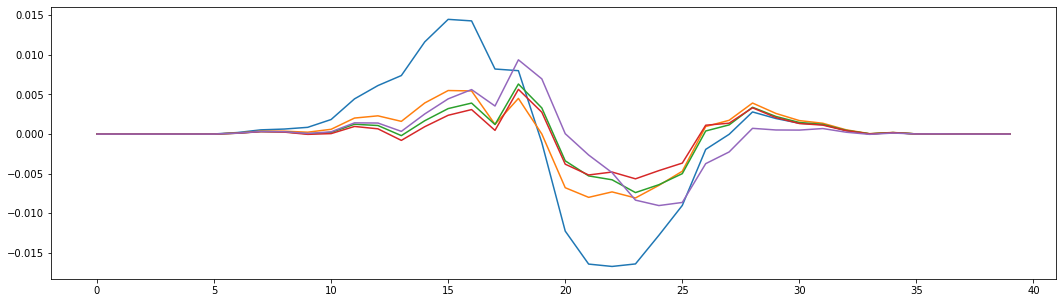

In [66]:
fig,ax = plt.subplots( 1, ndim, figsize=(18,5))

for ofi in range(of_niter) :
    for di in range( ndim ) :
        if ndim > 1 :
            thisax = ax[di]
        else :
            thisax = ax
        thisax.plot(det_hist_data_diff[ofi,di])

    
plt.show   

<function matplotlib.pyplot.show(close=None, block=None)>

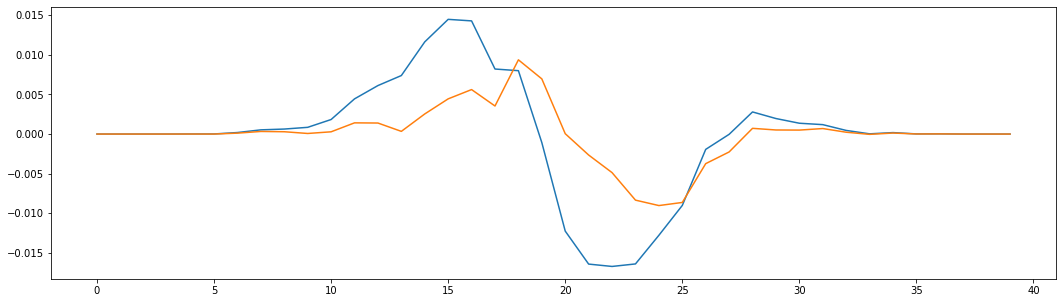

In [67]:
fig,ax = plt.subplots( 1, ndim, figsize=(18,5))

ofi = 0
for di in range( ndim ) :
    if ndim > 1 :
        thisax = ax[di]
    else :
        thisax = ax
    thisax.plot(det_hist_data_diff[ofi,di])

ofi = of_niter-1
for di in range( ndim ) :
    if ndim > 1 :
        thisax = ax[di]
    else :
        thisax = ax
    thisax.plot(det_hist_data_diff[ofi,di])

    
plt.show  

<function matplotlib.pyplot.show(close=None, block=None)>

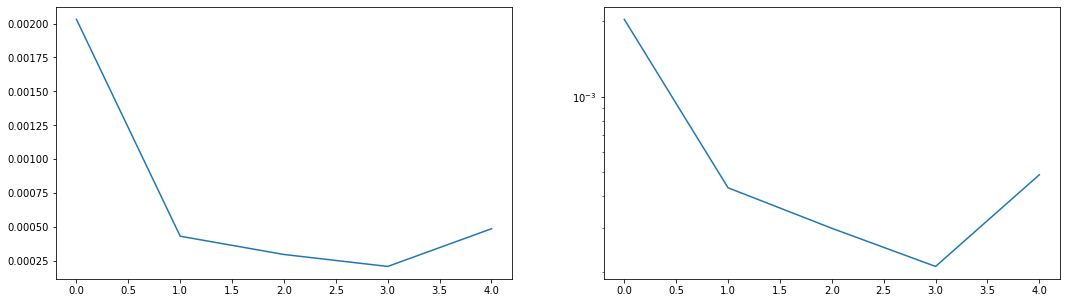

In [68]:
fig,ax = plt.subplots( 1, 2, figsize=(18,5))
ax[0].plot( det_hist_data_sum_diff2)
ax[1].plot( det_hist_data_sum_diff2)
ax[1].set_yscale('log')
plt.show

In [69]:
step1_mean = np.zeros( of_niter )
step1_rms = np.zeros( of_niter )

step2_mean = np.zeros( of_niter )
step2_rms = np.zeros( of_niter )

iter_val = np.zeros( of_niter )

for ofi in range( of_niter ) :
    
    iter_val[ofi] = ofi
    
    step1_mean[ofi] = np.mean( of_weights[ofi,0,:] )
    step1_rms[ofi] = np.sqrt( np.var( of_weights[ofi,0,:]))
    
    step2_mean[ofi] = np.mean( of_weights[ofi,1,:] )
    step2_rms[ofi] = np.sqrt( np.var( of_weights[ofi,1,:]))
    
    print("  iter %2d : step 1 mean  %.3f  rms %.3f      step 2 mean  %.3f  rms %.3f" % 
          (ofi, step1_mean[ofi], step1_rms[ofi], step2_mean[ofi], step2_rms[ofi]) )

  iter  0 : step 1 mean  1.001  rms 0.181      step 2 mean  1.002  rms 0.160
  iter  1 : step 1 mean  0.993  rms 0.064      step 2 mean  0.995  rms 0.055
  iter  2 : step 1 mean  0.995  rms 0.025      step 2 mean  0.992  rms 0.021
  iter  3 : step 1 mean  0.989  rms 0.018      step 2 mean  0.994  rms 0.010
  iter  4 : step 1 mean  1.014  rms 0.030      step 2 mean  1.015  rms 0.028


<function matplotlib.pyplot.show(close=None, block=None)>

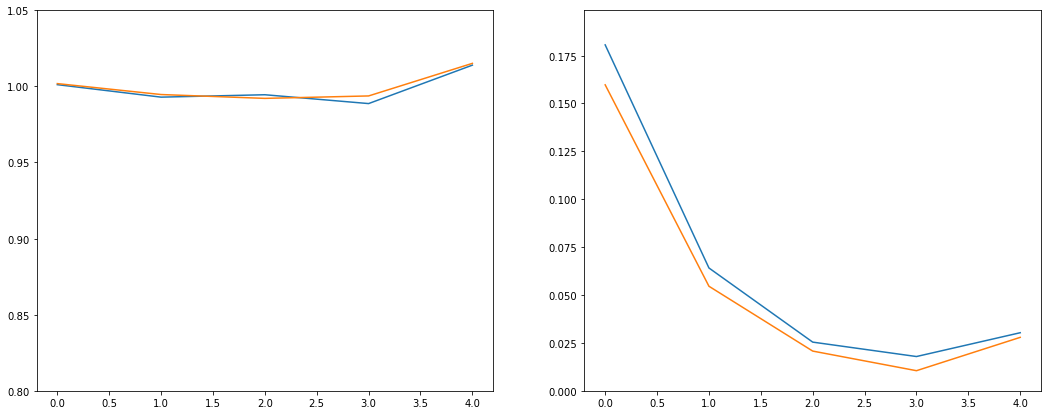

In [70]:
fig,ax = plt.subplots( 1, 2, figsize=(18,7))

ax[0].plot( iter_val, step1_mean )
ax[0].plot( iter_val, step2_mean )
ax[0].set_ylim( 0.80, 1.05)

ax[1].plot( iter_val, step1_rms )
ax[1].plot( iter_val, step2_rms )
ax[1].set_ylim( 0, 1.1*np.max(step1_rms))


plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

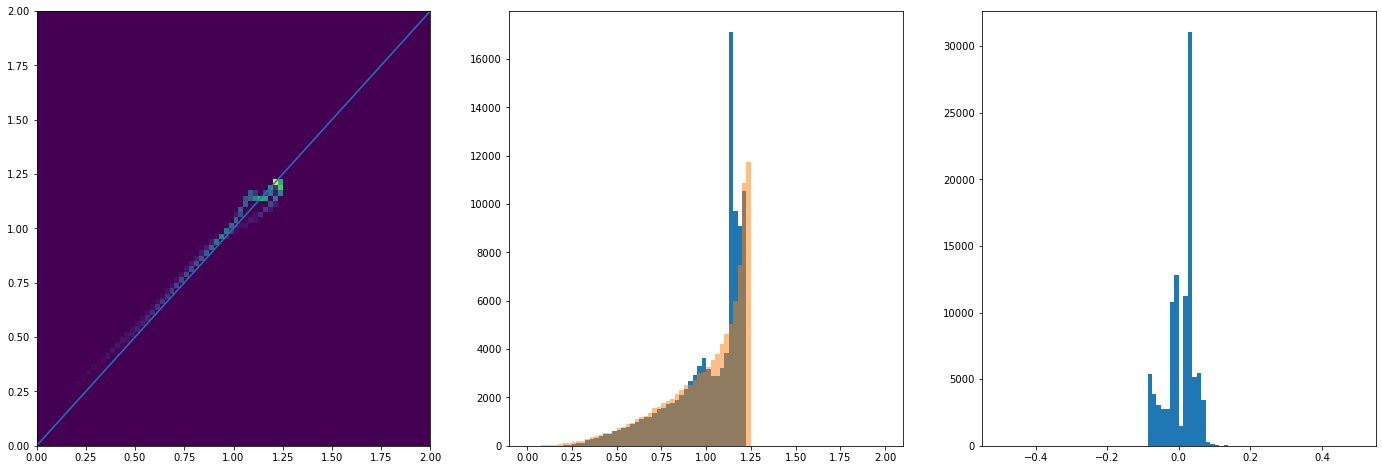

In [71]:
fig,ax = plt.subplots( 1, 3, figsize=(3*8,1*8))
max_weight = 2.0

ax[0].hist2d( calc_weight, final_push_weights, bins=[80,80], range=([0,max_weight],[0,max_weight]))
ax[0].plot([0,max_weight],[0,max_weight])

ax[1].hist( final_push_weights, bins=80, range=[0,max_weight] )
ax[1].hist( calc_weight, bins=80, range=[0,max_weight], alpha=0.5 )

ax[2].hist( final_push_weights-calc_weight, bins=80, range=[-0.5,0.5] )

plt.show

In [72]:

delta_weight_rms = np.sqrt( np.var( np.clip(final_push_weights-calc_weight,-0.5,0.5 ) ) )
print('\n\n Delta weight RMS:  %.5f\n\n' % delta_weight_rms )



 Delta weight RMS:  0.03920




## Monitoring of the OmniFold internal details

In [73]:
def profile2d( axis, xvals, yvals, hbins, hrange, drawhist=True, drawline=False ) :
    
    hist_data = axis.hist2d( xvals, yvals, bins=hbins, range=hrange)
    
    if not drawhist :
        axis.cla()

    nybins = len(hist_data[0][0])
    print("number of y bins: %d" % nybins)

    nxbins = len(hist_data[0])
    print("number of x bins: %d" % nxbins)



    x_vals = np.zeros( nxbins )
    avey_vals = np.zeros( nxbins )
    rmsy_vals = np.zeros( nxbins )

    for xbi in range( nxbins ) :

        wsum = 0
        ywsum = 0
        yywsum = 0

        xval = 0.5 * ( hist_data[1][xbi] + hist_data[1][xbi+1] )
        #print(" xbin %d has center at %6.3f" % ( xbin_ind, xval ))

        for ybi in range( nybins ) :  
            yval = 0.5 * ( hist_data[2][ybi] + hist_data[2][ybi+1] )
            bin_content = hist_data[0][xbi][ybi]
            wsum = wsum + bin_content
            ywsum = ywsum + yval * bin_content
            yywsum = yywsum + yval * yval * bin_content
            #print("  %3d : y = %6.3f  bin content = %7d" % (bi, yval, bin_content))

        ave_y = ywsum / wsum
        ave_yy = yywsum / wsum
        rms_y = ave_yy - ave_y * ave_y
        #print(" Ave y = %.3f, RMS y = %.3f" % ( ave_y, rms_y) )

        x_vals[xbi] = xval
        avey_vals[xbi] = ave_y
        rmsy_vals[xbi] = rms_y


    #for xbi in range( nxbins ) :
        #print("  %4d :  x = %7.3f   ave y = %7.3f  rms y = %7.3f" % ( xbi, x_vals[xbi], avey_vals[xbi], rmsy_vals[xbi]))

    if drawline :
        axis.plot( (hist_data[1][0], hist_data[1][-1]), (0,0) )  
    
    axis.errorbar( x_vals, avey_vals, yerr=rmsy_vals, fmt='-', linewidth=5)

    
    plt.show
    

In [74]:
of_return_dict

{'train-hist-step1-iter0': <keras.src.callbacks.history.History at 0x7eabb2599c30>,
 'model_weights_step1_iter0': array([[-0.18337049,  0.24137098,  0.2952165 , -0.10861957, -0.33273217,
         -0.25754705,  0.02299808, -0.31936184,  0.19748391, -0.14598723,
          0.09579035, -0.27132586,  0.0889059 , -0.1151632 ,  0.01351311,
         -0.29528594, -0.12546   , -0.02739045,  0.3151279 , -0.1560734 ,
         -0.27210915, -0.0820208 ,  0.078364  ,  0.28131995,  0.14918329,
         -0.18123174,  0.27107948, -0.1521236 , -0.21271296, -0.21199279,
         -0.29381   ,  0.16206814,  0.0141552 , -0.28821576, -0.35103935,
         -0.11663595, -0.06210031,  0.04565504,  0.23990971,  0.14790009,
          0.1837523 , -0.09164184, -0.11882171,  0.22682321, -0.03668079,
         -0.07974806, -0.01769972,  0.17390333,  0.29687157,  0.2902176 ]],
       dtype=float32),
 'model_biases_step1_iter0': array([ 0.00987094, -0.01299158, -0.02067651, -0.00850474, -0.00808773,
        -0.00522348, 

In [75]:
of_return_dict['weights'].shape

(5, 2, 100000)

In [76]:
of_return_dict['weights'][0,1,:]

array([1.13078916, 0.933936  , 0.95402008, ..., 1.07555306, 1.11011732,
       0.89989585])

In [77]:
of_return_dict['push_weights'][0]

array([1.13078916, 0.933936  , 0.95402008, ..., 1.07555306, 1.11011732,
       0.89989585])

In [78]:
train_pts[:,0].shape

(100000,)

In [79]:
of_prob = of_return_dict['weights'] / (1. + of_return_dict['weights'] )

In [80]:
of_prob

array([[[0.52290298, 0.47864391, 0.39412385, ..., 0.53197282,
         0.52389066, 0.49216022],
        [0.53069031, 0.48291981, 0.48823453, ..., 0.51820071,
         0.5260927 , 0.47365536]],

       [[0.50689935, 0.49530043, 0.46427025, ..., 0.50896835,
         0.50603724, 0.49703028],
        [0.50801719, 0.49400895, 0.49567539, ..., 0.50316255,
         0.50833626, 0.49116693]],

       [[0.49518019, 0.49879175, 0.48957526, ..., 0.4949585 ,
         0.4971028 , 0.49967469],
        [0.49744362, 0.49866675, 0.49920839, ..., 0.50430203,
         0.49903201, 0.49749858]],

       [[0.49666417, 0.49702681, 0.49169315, ..., 0.49234606,
         0.49325015, 0.49980873],
        [0.50132812, 0.49833165, 0.498182  , ..., 0.50036675,
         0.49516127, 0.49827884]],

       [[0.48675956, 0.49965943, 0.51151348, ..., 0.50364321,
         0.50687344, 0.49826616],
        [0.48774805, 0.50544662, 0.50507164, ..., 0.5089482 ,
         0.5048713 , 0.50590521]]])

number of y bins: 2000
number of x bins: 200


/tmp/ipykernel_2640954/2115069057.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_2640954/2115069057.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 2000
number of x bins: 200


/tmp/ipykernel_2640954/2115069057.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_2640954/2115069057.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 2000
number of x bins: 200


...

number of y bins: 2000
number of x bins: 200


/tmp/ipykernel_2640954/2115069057.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_2640954/2115069057.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 2000
number of x bins: 200


/tmp/ipykernel_2640954/2115069057.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_2640954/2115069057.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


<function matplotlib.pyplot.show(close=None, block=None)>

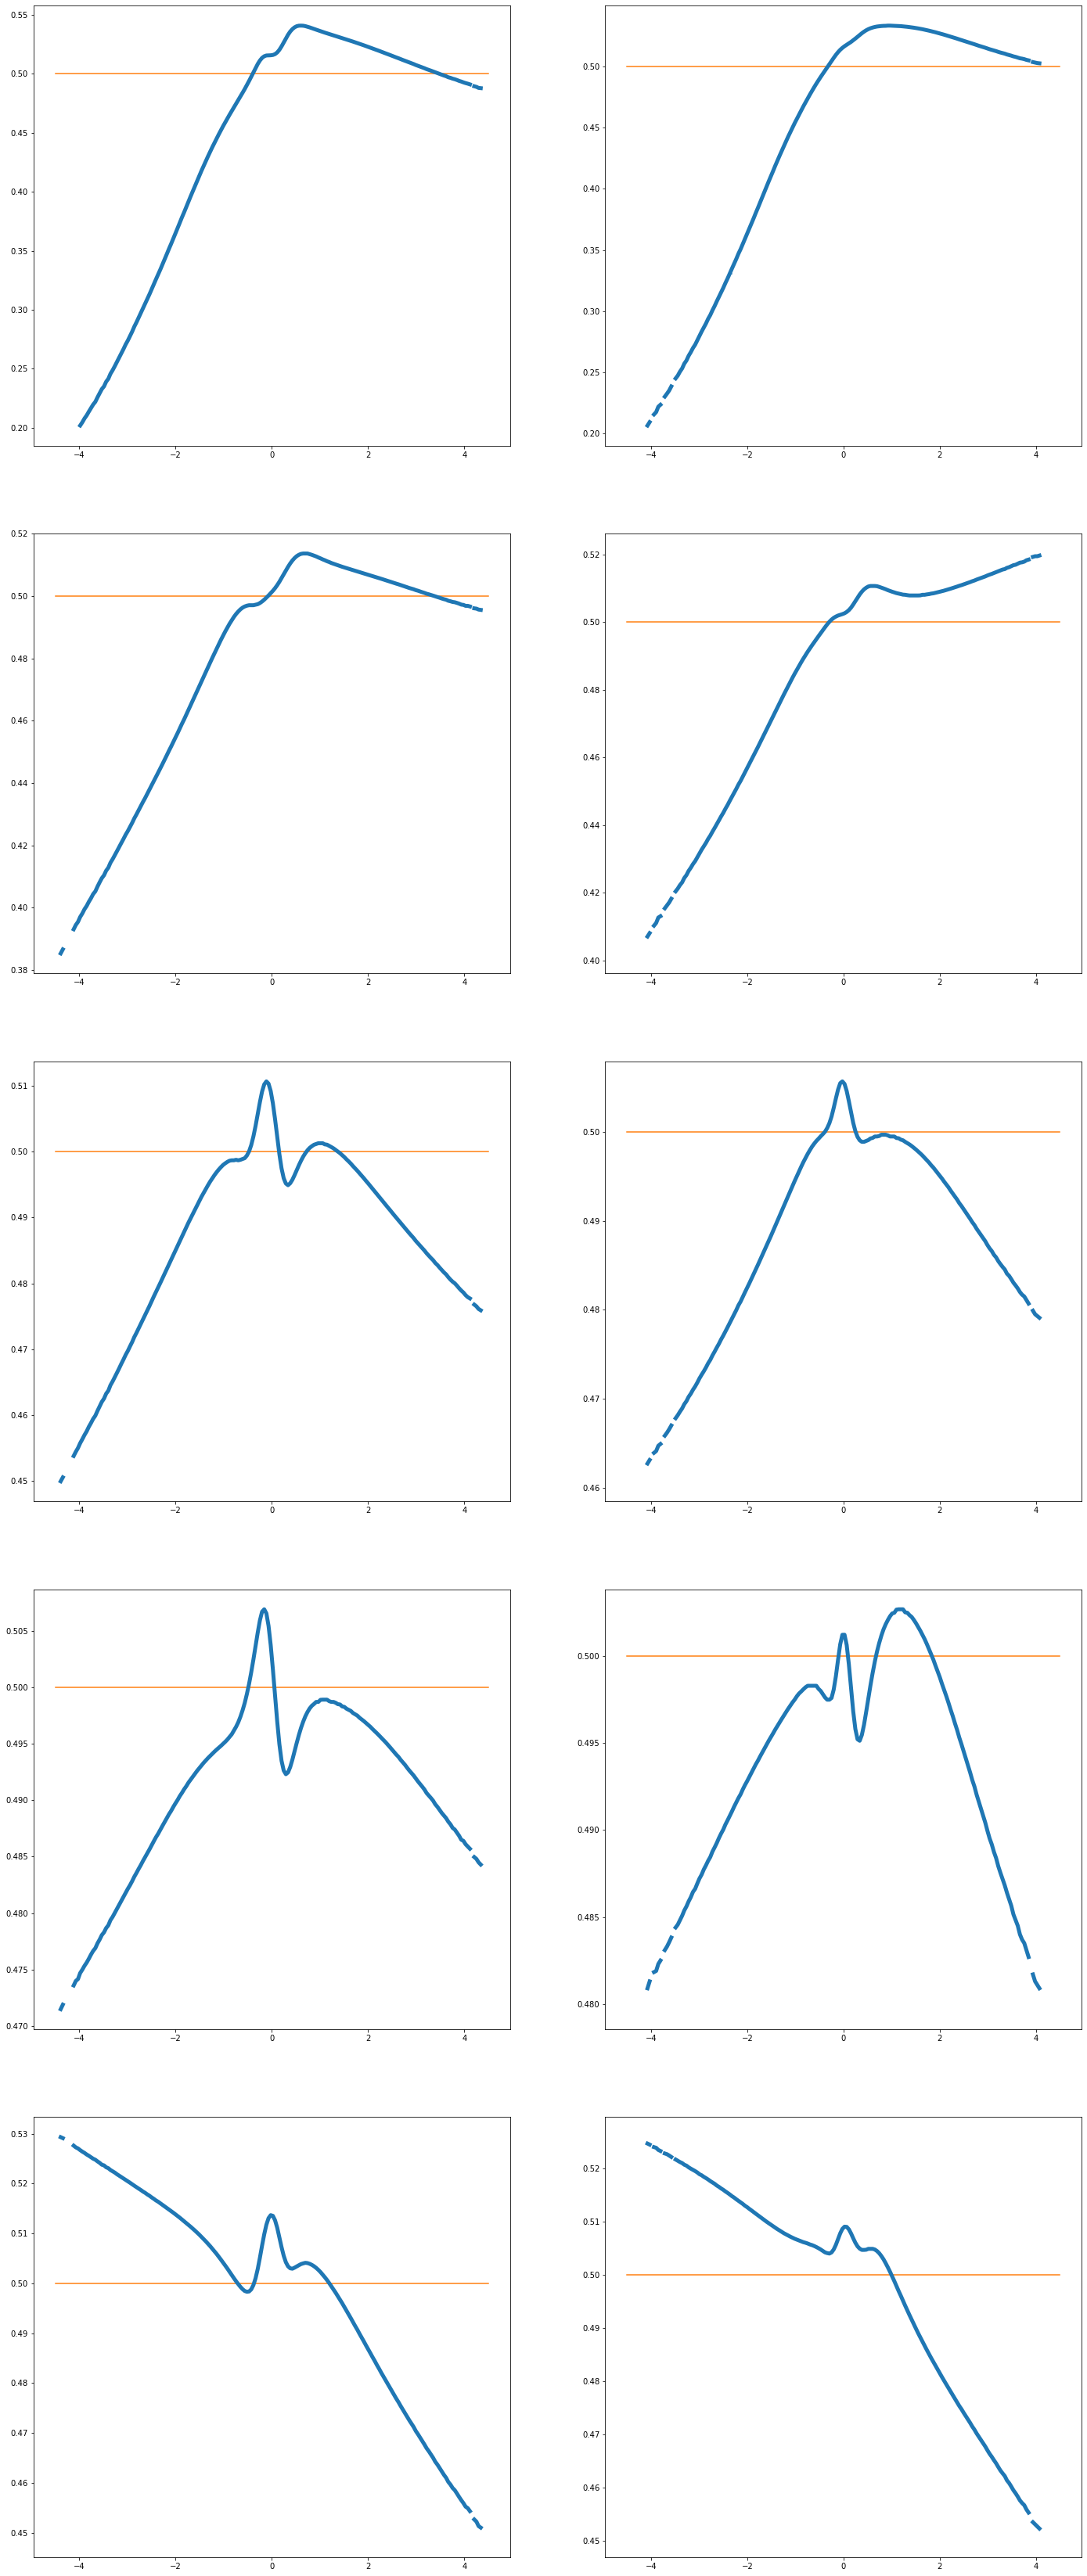

In [81]:
fig,ax = plt.subplots( of_niter, 2, figsize=(2*12,of_niter*12))

xmin = -4.5
xmax = 4.5

ymin = 0.2
ymax = 0.6

for ofi in range( of_niter ) :

    profile2d( ax[ofi][0], train_det_pts[:,0], of_prob[ofi,0,:], 
          hbins=[200,2000], hrange=([xmin,xmax],[ymin,ymax]), drawhist=False, drawline=False ) 
    ax[ofi][0].plot([xmin,xmax],[0.5,0.5])
    
    profile2d( ax[ofi][1], train_pts[:,0], of_prob[ofi,1,:], 
          hbins=[200,2000], hrange=([-4.5,4.5],[ymin,ymax]), drawhist=False, drawline=False ) 
    ax[ofi][1].plot([xmin,xmax],[0.5,0.5])

plt.show

In [82]:
def prob_from_hists( points_a, points_b, weights_a, weights_b, hnbins, hxmin, hxmax ) :
    
    hbw = (hxmax-hxmin)/hnbins
    
    #-- calculate bin indices
    bin_indices_a = np.array( (points_a - hxmin)/hbw, dtype=int )
    bin_indices_b = np.array( (points_b - hxmin)/hbw, dtype=int )
    
    
    hist_binsum_a = np.zeros( hnbins )
    hist_binsum_b = np.zeros( hnbins )
    
    hist_err_a = np.zeros( hnbins )
    hist_err_b = np.zeros( hnbins )
    
    hist_ratio = np.zeros( hnbins )
    hist_ratio_err = np.zeros( hnbins )
    
    sample_wsum_a = np.sum(weights_a)
    sample_wsum_b = np.sum(weights_b)

    
    for bi in range( hnbins ) :
        hist_binsum_a[bi] = np.sum( weights_a[ bin_indices_a == bi ] ) / sample_wsum_a
        hist_binsum_b[bi] = np.sum( weights_b[ bin_indices_b == bi ] ) / sample_wsum_b
        hist_err_a[bi] = np.sqrt( np.sum( np.square( weights_a[ bin_indices_a == bi ] ) ) ) / sample_wsum_a
        hist_err_b[bi] = np.sqrt( np.sum( np.square( weights_b[ bin_indices_b == bi ] ) ) ) / sample_wsum_b
        if hist_binsum_b[bi] > 0 :
            hist_ratio[bi] = hist_binsum_b[bi] / (hist_binsum_a[bi] + hist_binsum_b[bi])
            if hist_binsum_a[bi] > 0 :
                hist_ratio_err[bi] = np.sqrt(
                    np.square( (hist_binsum_b[bi]/np.square(hist_binsum_b[bi]+hist_binsum_a[bi])) * hist_err_a[bi] ) +
                    np.square( (hist_binsum_a[bi]/np.square(hist_binsum_b[bi]+hist_binsum_a[bi])) * hist_err_b[bi] )
                )
        
    return_dict = {}
    return_dict['hist_binsum_a'] = hist_binsum_a
    return_dict['hist_binsum_b'] = hist_binsum_b
    return_dict['hist_err_a'] = hist_err_a
    return_dict['hist_err_b'] = hist_err_b
    return_dict['hist_ratio'] = hist_ratio
    return_dict['hist_ratio_err'] = hist_ratio_err
    
    return return_dict
    

## Examine the Likelihood Ratio output for Step 1 in OmniFold for each iteration

number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_2640954/2115069057.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_2640954/2115069057.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_2640954/2115069057.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_2640954/2115069057.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 1000
number of x bins: 1000


...

number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_2640954/2115069057.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_2640954/2115069057.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_2640954/2115069057.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_2640954/2115069057.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


<function matplotlib.pyplot.show(close=None, block=None)>

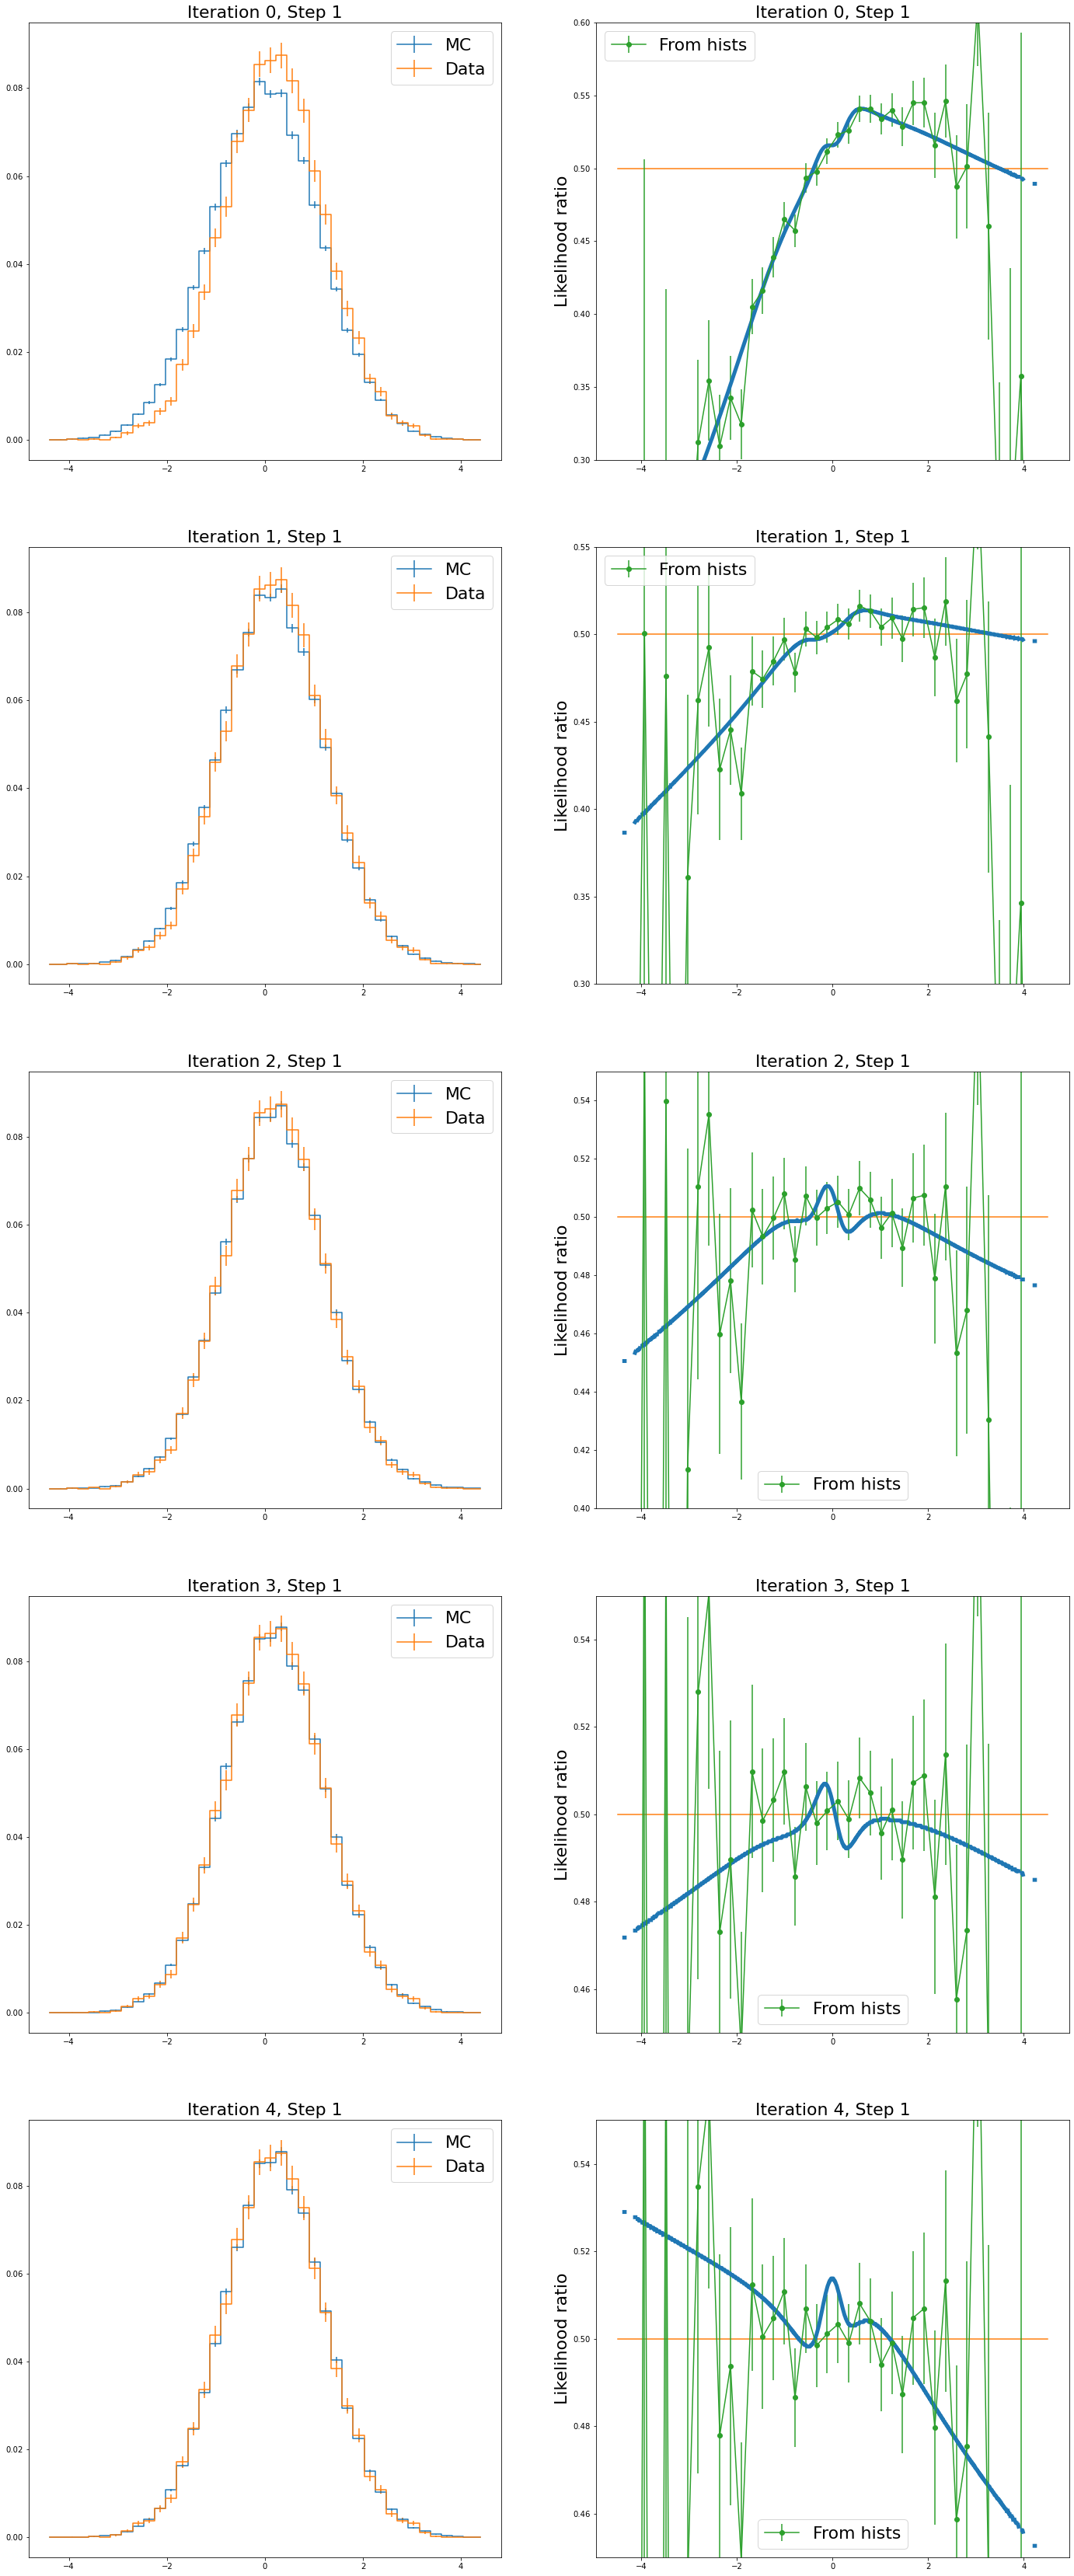

In [83]:

hxmin = -4.5
hxmax = 4.5


hnbins = 40



hbw = (hxmax-hxmin) / hnbins

xvals = np.zeros( hnbins )
for bi in range( hnbins ) :
    xvals[bi] = hxmin + (0.5 + bi)*hbw

nnbins = 1000

plotymin=[0.30, 0.30, 0.40, 0.45, 0.45]
plotymax=[0.60, 0.55, 0.55, 0.55, 0.55]


#plotymin=[0.30, 0.45, 0.49, 0.49, 0.49]
#plotymax=[0.60, 0.55, 0.51, 0.51, 0.51]



fig,ax = plt.subplots( of_niter, 2, figsize=(2*12,of_niter*12))


for ofi in range( of_niter ) :
    
    weights_ones_b = np.ones( len(true_det_pts[:,0]) )

    if ofi==0 :        
        weights_a = np.ones( len(train_det_pts[:,0]) )        
    else :
        weights_a = of_return_dict['push_weights'][ofi-1]

    rd = prob_from_hists( train_det_pts[:,0], 
                             true_det_pts[:,0], 
                             weights_a, 
                             weights_ones_b, 
                             hnbins, hxmin, hxmax )

    axi = ax[ofi][0]
    axi.errorbar( xvals, rd['hist_binsum_a'], rd['hist_err_a'], drawstyle='steps-mid', label='MC')
    axi.errorbar( xvals, rd['hist_binsum_b'], rd['hist_err_b'], drawstyle='steps-mid', label='Data')
    axi.legend( fontsize=22 )
    axi.set_title('Iteration %d, Step 1' % ofi, fontsize=22 )
        
    axi = ax[ofi][1]
    profile2d( axi, train_det_pts[:,0], of_prob[ofi,0,:], 
          hbins=[nnbins,nnbins], hrange=([xmin,xmax],[ymin,ymax]), drawhist=False, drawline=False ) 
    axi.plot([hxmin,hxmax],[0.5,0.5])
    axi.errorbar(xvals,rd['hist_ratio'],rd['hist_ratio_err'], marker='o', linestyle='-', label='From hists')
    axi.legend( fontsize=22 )
    axi.set_ylabel('Likelihood ratio', fontsize=22 )
    
    axi.set_ylim( plotymin[ofi], plotymax[ofi] )
    axi.set_title('Iteration %d, Step 1' % ofi, fontsize=22 )
        

        
        
plt.show

number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_2640954/2115069057.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_2640954/2115069057.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_2640954/2115069057.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_2640954/2115069057.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 1000
number of x bins: 1000


...

number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_2640954/2115069057.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_2640954/2115069057.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_2640954/2115069057.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_2640954/2115069057.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


<function matplotlib.pyplot.show(close=None, block=None)>

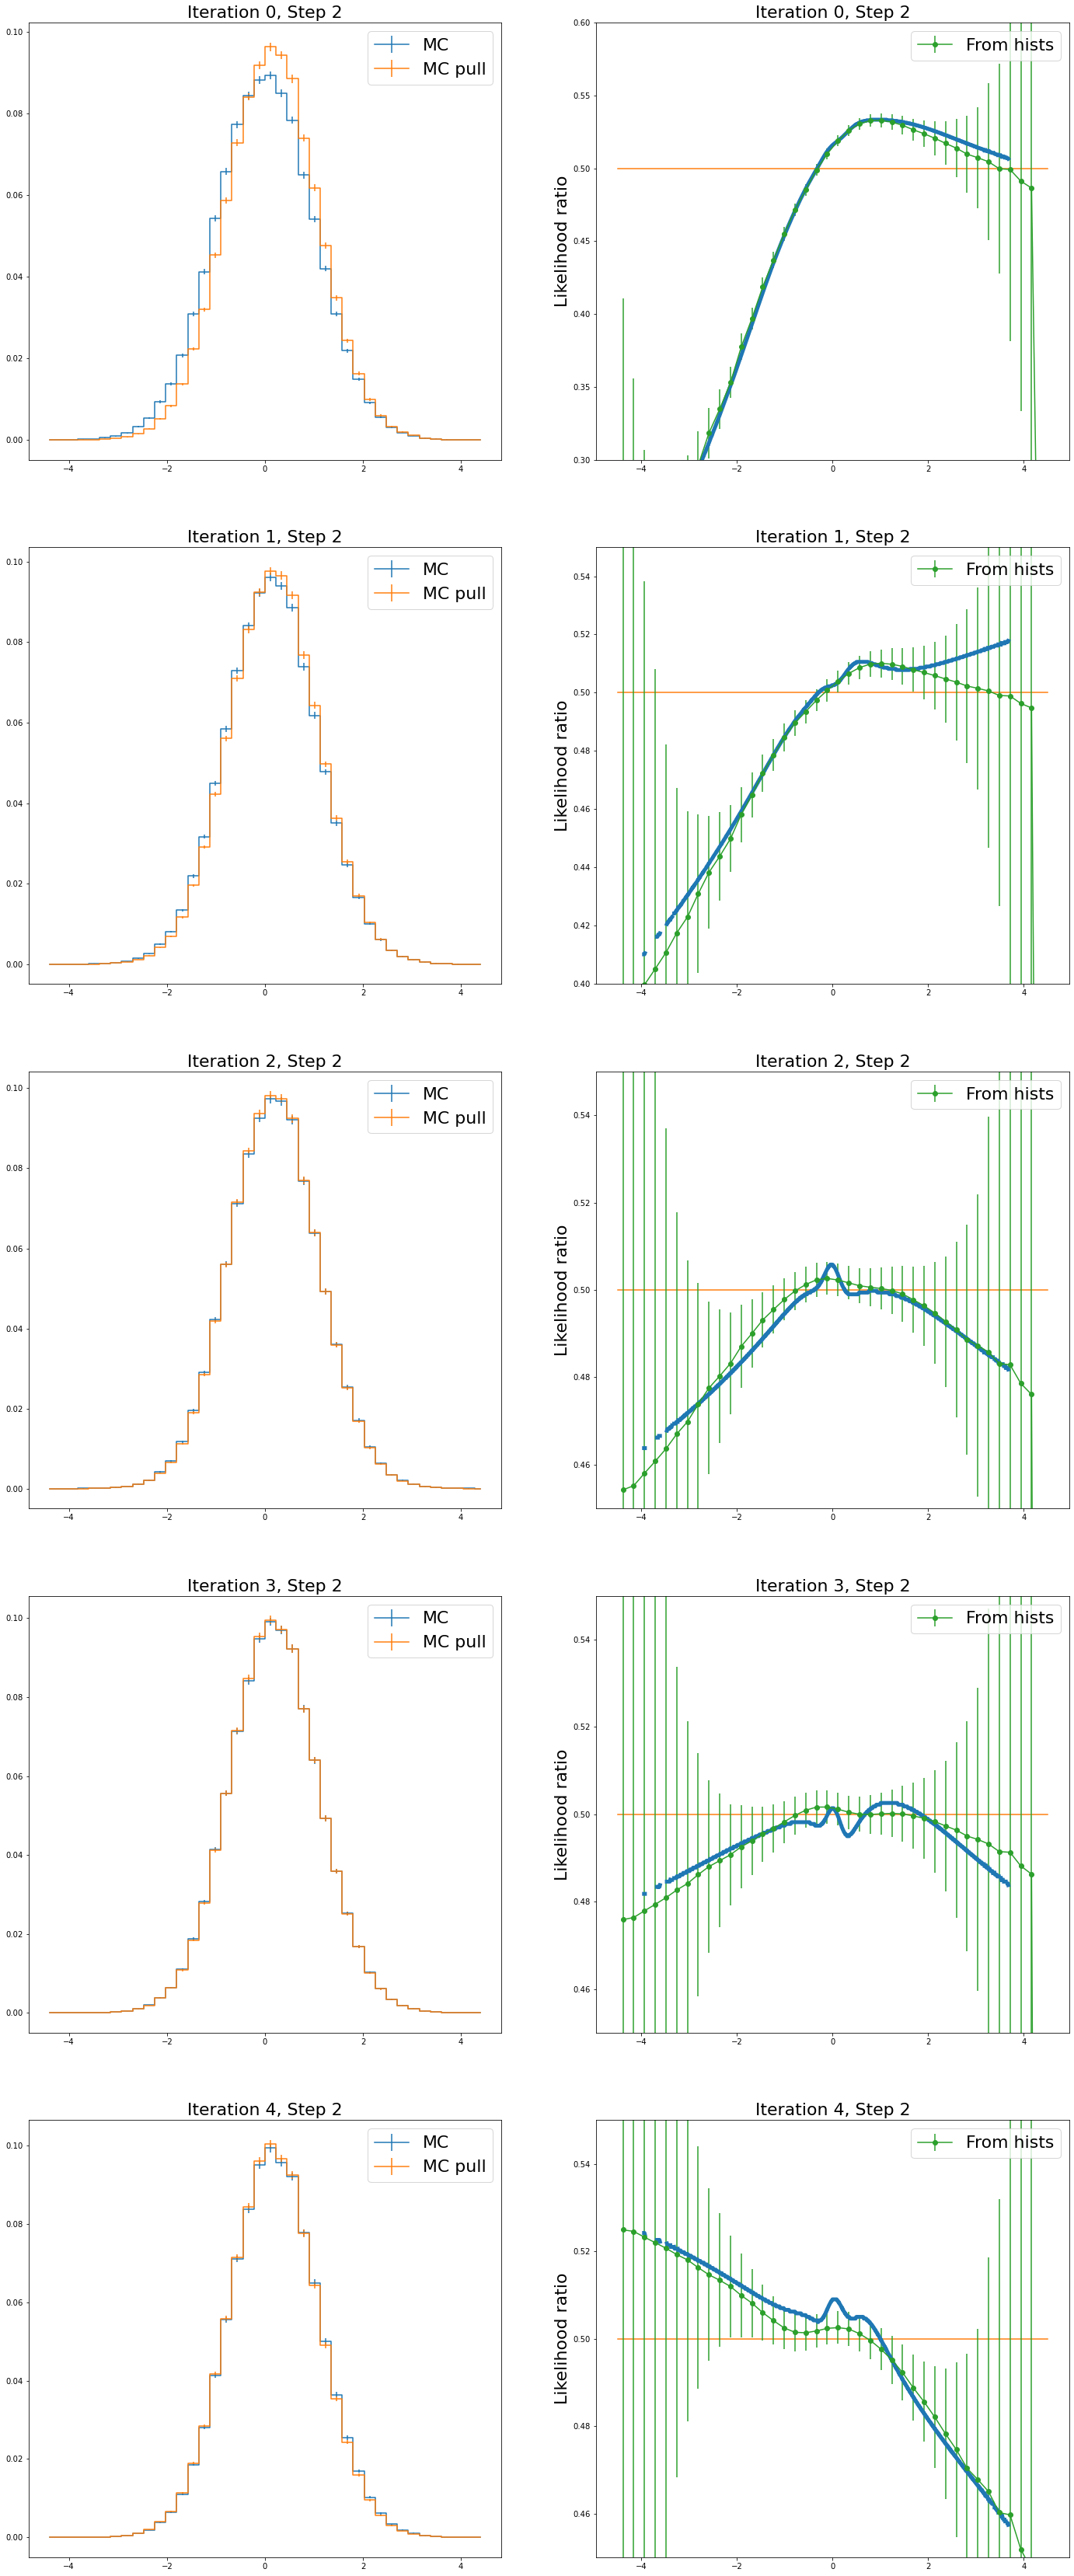

In [84]:

hxmin = -4.5
hxmax = 4.5


hnbins = 40



hbw = (hxmax-hxmin) / hnbins

xvals = np.zeros( hnbins )
for bi in range( hnbins ) :
    xvals[bi] = hxmin + (0.5 + bi)*hbw

nnbins = 1000

plotymin=[0.30, 0.40, 0.45, 0.45, 0.45]
plotymax=[0.60, 0.55, 0.55, 0.55, 0.55]

#plotymin=[0.30, 0.45, 0.49, 0.49, 0.49]
#plotymax=[0.60, 0.55, 0.51, 0.51, 0.51]





fig,ax = plt.subplots( of_niter, 2, figsize=(2*12,of_niter*12))


for ofi in range( of_niter ) :
    
    previous_push_weights = np.ones( len(train_pts[:,0]))
    if ofi > 0 :
        previous_push_weights = of_return_dict['push_weights'][ofi-1]
                
    pull_weights = previous_push_weights * of_return_dict['weights'][ofi,0,:]
    


    rd = prob_from_hists( train_pts[:,0], 
                             train_pts[:,0], 
                             previous_push_weights, 
                             pull_weights, 
                             hnbins, hxmin, hxmax )

    axi = ax[ofi][0]
    axi.errorbar( xvals, rd['hist_binsum_a'], rd['hist_err_a'], drawstyle='steps-mid', label='MC')
    axi.errorbar( xvals, rd['hist_binsum_b'], rd['hist_err_b'], drawstyle='steps-mid', label='MC pull')
    axi.legend( fontsize=22 )
    axi.set_title('Iteration %d, Step 2' % ofi, fontsize=22 )
        
    axi = ax[ofi][1]
    profile2d( axi, train_pts[:,0], of_prob[ofi,1,:], 
          hbins=[nnbins,nnbins], hrange=([xmin,xmax],[ymin,ymax]), drawhist=False, drawline=False ) 
    axi.plot([hxmin,hxmax],[0.5,0.5])
    axi.errorbar(xvals,rd['hist_ratio'],rd['hist_ratio_err'], marker='o', linestyle='-', label='From hists')
    axi.legend( fontsize=22 )
    axi.set_ylabel('Likelihood ratio', fontsize=22 )
    
    axi.set_ylim( plotymin[ofi], plotymax[ofi] )
    axi.set_title('Iteration %d, Step 2' % ofi, fontsize=22 )
        

        
        
plt.show

In [85]:
of_return_dict.keys()

dict_keys(['train-hist-step1-iter0', 'model_weights_step1_iter0', 'model_biases_step1_iter0', 'train-hist-step2-iter0', 'model_weights_step2_iter0', 'model_biases_step2_iter0', 'train-hist-step1-iter1', 'model_weights_step1_iter1', 'model_biases_step1_iter1', 'train-hist-step2-iter1', 'model_weights_step2_iter1', 'model_biases_step2_iter1', 'train-hist-step1-iter2', 'model_weights_step1_iter2', 'model_biases_step1_iter2', 'train-hist-step2-iter2', 'model_weights_step2_iter2', 'model_biases_step2_iter2', 'train-hist-step1-iter3', 'model_weights_step1_iter3', 'model_biases_step1_iter3', 'train-hist-step2-iter3', 'model_weights_step2_iter3', 'model_biases_step2_iter3', 'train-hist-step1-iter4', 'model_weights_step1_iter4', 'model_biases_step1_iter4', 'train-hist-step2-iter4', 'model_weights_step2_iter4', 'model_biases_step2_iter4', 'weights', 'push_weights', 'final_push_weights'])

In [86]:
s1_weights, s1_biases = model_step1.layers[0].get_weights()

<function matplotlib.pyplot.show(close=None, block=None)>

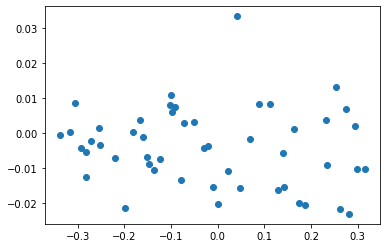

In [87]:
plt.scatter( s1_weights, s1_biases )
plt.show

In [88]:
s2_weights, s2_biases = model_step2.layers[0].get_weights()

<function matplotlib.pyplot.show(close=None, block=None)>

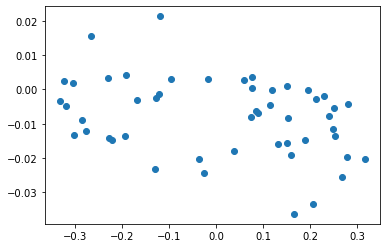

In [89]:
plt.scatter( s2_weights, s2_biases )
plt.show

In [90]:
w,b = model_step1.layers[2].get_weights()

In [91]:
w.shape

(50, 50)

In [92]:
s1_weights.shape

(1, 50)

<function matplotlib.pyplot.show(close=None, block=None)>

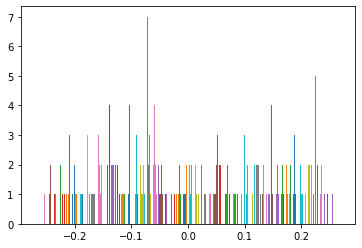

In [93]:
plt.hist( w, bins=50)
plt.show

In [94]:
of_return_dict['model_weights_step1_iter0'][0].shape

(50,)

<function matplotlib.pyplot.show(close=None, block=None)>

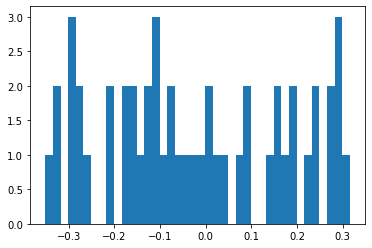

In [95]:
plt.hist(  of_return_dict['model_weights_step1_iter0'][0], bins=40  )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

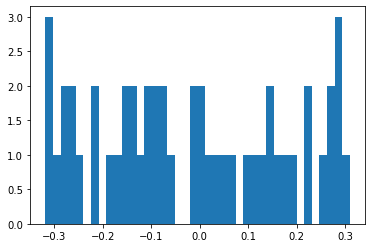

In [96]:
plt.hist(  of_return_dict['model_weights_step1_iter1'][0], bins=40  )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

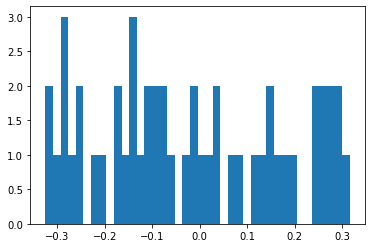

In [97]:
plt.hist(  of_return_dict['model_weights_step1_iter2'][0], bins=40  )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

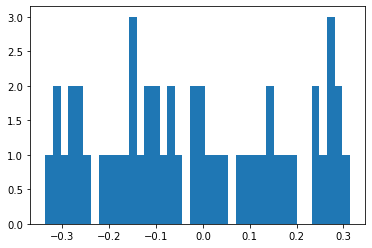

In [98]:
plt.hist(  of_return_dict['model_weights_step1_iter3'][0], bins=40  )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

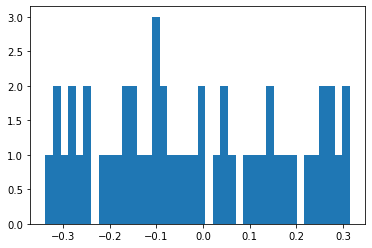

In [99]:
plt.hist(  of_return_dict['model_weights_step1_iter4'][0], bins=40  )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

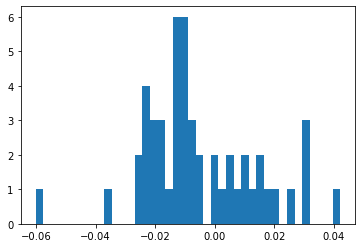

In [100]:
plt.hist(  of_return_dict['model_biases_step1_iter0'], bins=40  )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

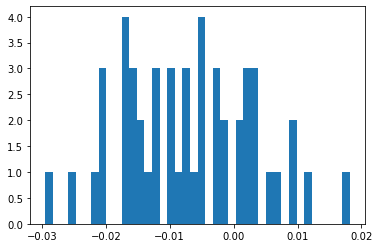

In [101]:
plt.hist(  of_return_dict['model_biases_step1_iter1'], bins=40  )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

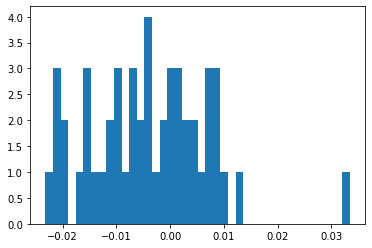

In [102]:
plt.hist(  of_return_dict['model_biases_step1_iter4'], bins=40  )
plt.show

In [103]:
model_step1

<Sequential name=sequential, built=True>

In [104]:
model_step1.layers

[<Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>,
 <Dropout name=dropout_1, built=True>,
 <Dense name=dense_2, built=True>,
 <Dropout name=dropout_2, built=True>,
 <Dense name=dense_3, built=True>]

In [105]:
model_step1.layers[0].get_weights()

[array([[-0.15165792,  0.23467389,  0.2993823 , -0.09201872, -0.31706017,
         -0.27079037,  0.02175228, -0.3377809 ,  0.18627211, -0.14807414,
          0.11243446, -0.25441578,  0.08942012, -0.10275259,  0.04230743,
         -0.28171152, -0.13670222, -0.00972825,  0.31464818, -0.16720708,
         -0.25188336, -0.07799572,  0.06936661,  0.26151913,  0.14064395,
         -0.1809468 ,  0.27400085, -0.16017745, -0.22127055, -0.1989991 ,
         -0.28143707,  0.1413712 ,  0.00037934, -0.29322284, -0.30664515,
         -0.12440348, -0.05080831,  0.0468946 ,  0.25342426,  0.12878448,
          0.17347683, -0.09716672, -0.10035663,  0.23160256, -0.02985165,
         -0.07176677, -0.02146178,  0.16257669,  0.28070167,  0.2943922 ]],
       dtype=float32),
 array([-0.00700525, -0.00910081, -0.01033742,  0.00749864,  0.00015139,
        -0.00222772, -0.01103533, -0.0004896 , -0.02068307, -0.0089821 ,
         0.00827802,  0.00137326,  0.00820227,  0.00790858,  0.03343974,
        -0.00538

In [106]:
for ni in range( units_per_layer ) :
    print(' node %3d :' % ni, end = '')
    for ii in range( of_niter ) :
        print( ' %7.4f ' % of_return_dict['model_weights_step1_iter%d' % ii][0,ni], end='' )
    print(' | ', end='')
    for ii in range( of_niter ) :
        print( ' %7.4f ' % of_return_dict['model_biases_step1_iter%d' % ii][ni], end='' )
    print()


 node   0 : -0.1834  -0.1506  -0.1440  -0.1531  -0.1517  |   0.0099  -0.0294  -0.0261  -0.0047  -0.0070 
 node   1 :  0.2414   0.2290   0.2385   0.2381   0.2347  |  -0.0130  -0.0200   0.0016   0.0036  -0.0091 
 node   2 :  0.2952   0.2910   0.2867   0.2902   0.2994  |  -0.0207   0.0015  -0.0177  -0.0183  -0.0103 
 node   3 : -0.1086  -0.0885  -0.0858  -0.0908  -0.0920  |  -0.0085  -0.0048  -0.0018  -0.0084   0.0075 
 node   4 : -0.3327  -0.3182  -0.3178  -0.3197  -0.3171  |  -0.0081  -0.0125  -0.0073  -0.0011   0.0002 
 node   5 : -0.2575  -0.2653  -0.2685  -0.2671  -0.2708  |  -0.0052   0.0088   0.0051  -0.0015  -0.0022 
 node   6 :  0.0230   0.0171   0.0178   0.0179   0.0218  |  -0.0167  -0.0163  -0.0085  -0.0126  -0.0110 
 node   7 : -0.3194  -0.3165  -0.3246  -0.3362  -0.3378  |  -0.0250  -0.0119   0.0108   0.0127  -0.0005 
 node   8 :  0.1975   0.1890   0.1890   0.1883   0.1863  |  -0.0149  -0.0159  -0.0124  -0.0149  -0.0207 
 node   9 : -0.1460  -0.1435  -0.1405  -0.1428  -0.1481

# Bootstrap / Toy MC below here

In [107]:
verbose = False



import gc

In [108]:
try:
    os.mkdir( "%s/bootstrap-nn-models" % output_dir )
except :
    print('problem creating bootstrap-nn-models dir')


In [109]:
%%time

rng = np.random.default_rng()

for bi in range(0,n_boot_samples) :
    
    this_random_seed = random_seed*10000+bi
    
    np.random.seed( this_random_seed )
    keras.utils.set_random_seed( this_random_seed )

    
    if do_bootstrap :
        print("\n Creating bootstrap sample %3d,  seed %d" % (bi, this_random_seed) )
        boot_true_det_pts = rng.choice( true_det_pts, size=len(true_det_pts) )
        
    else :
        this_ngen_true = ngen_true
        if use_poisson_fluctuations_around_ngen_true : this_ngen_true = np.random.poisson( ngen_true )
        print("\n Creating toy sample %3d,  this_ngen_true = %d, seed %d" % (bi, this_ngen_true, this_random_seed) )
        boot_true_pts = np.random.multivariate_normal(true_mu, true_cov, size=this_ngen_true)
        boot_true_det_pts = np.random.normal( boot_true_pts, resolution )
        
    modeldir = "%s/bootstrap-nn-models/bs-%03d" % (output_dir, bi) 
    
    try:
        os.mkdir( modeldir )
    except :
        print('\n\n *** probelm creating model output directory : %s' % modeldir )

        

    #-- Reset the model to ensure fresh random weights for each bootstrap



    reg_setval_zero = 0.0


    model_step1 = Sequential()

    model_step1.add( Dense(units_per_layer, input_dim=ndim, activation=activation_setval, 
                           kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                           bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                           activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
    if use_batch_norm : model_step1.add( BatchNormalization() )
    model_step1.add( Dropout(dropout_setval) )

    if number_of_layers > 1 :
        model_step1.add( Dense(units_per_layer, activation=activation_setval, 
                           kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                           bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval), 
                           activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
        if use_batch_norm : model_step1.add( BatchNormalization() )
        model_step1.add( Dropout(dropout_setval) )

    if number_of_layers > 2 :
        model_step1.add( Dense(units_per_layer, activation=activation_setval, 
                           kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                           bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                           activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
        if use_batch_norm : model_step1.add( BatchNormalization() )
        model_step1.add( Dropout(dropout_setval) )

    model_step1.add( Dense(1, activation='sigmoid') )





    model_step2 = Sequential()

    model_step2.add( Dense(units_per_layer, input_dim=ndim, activation=activation_setval, 
                           kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                           bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval), 
                           activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
    if use_batch_norm : model_step2.add( BatchNormalization() )
    model_step2.add( Dropout(dropout_setval) )

    if number_of_layers > 1 :
        model_step2.add( Dense(units_per_layer, activation=activation_setval, 
                           kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                           bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                           activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
        if use_batch_norm : model_step2.add( BatchNormalization() )
        model_step2.add( Dropout(dropout_setval) )

    if number_of_layers > 2 :
        model_step2.add( Dense(units_per_layer, activation=activation_setval, 
                           kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                           bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                           activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
        if use_batch_norm : model_step2.add( BatchNormalization() )
        model_step2.add( Dropout(dropout_setval) )

    model_step2.add( Dense(1, activation='sigmoid') )


    #----








    opt_step1 = tf.keras.optimizers.Adam( learning_rate=learning_rate_setval )
    ##########opt_step2 = tf.keras.optimizers.Adam( learning_rate=(0.04*learning_rate_setval) )  # owen: use lower learning rate in step 2
    opt_step2 = tf.keras.optimizers.Adam( learning_rate=learning_rate_setval )



    model_step1.compile(loss=weighted_binary_crossentropy,
                          optimizer=opt_step1,
                          metrics=['accuracy'])

    model_step2.compile(loss=weighted_binary_crossentropy,
                          optimizer=opt_step2,
                          metrics=['accuracy'])

    
    
    
    
    
    ##-----------  Begin OmniFold
    
    
        
    #boot_of_return_dict = of.omnifold9b( 
    #    train_both, boot_true_det_pts, of_niter, model_step1, model_step2, verbose, 
    #    batch_size_setval, epochs_setval, True, modeldir )

    theta0 = train_both
    theta_unknown_S = boot_true_det_pts  #--- fixed bug here.
    iterations = of_niter
    verbose = False

    weights = np.empty(shape=(iterations, 2, len(theta0)))
    # shape = (iteration, step, event)
    push_weights_for_output = np.empty(shape=(iterations, len(theta0)))

    theta0_G = theta0[:,0]
    theta0_S = theta0[:,1]

    labels0 = np.zeros(len(theta0))
    labels_unknown = np.ones(len(theta_unknown_S))
    labels_unknown_step2 = np.ones(len(theta0_G))

    pretrain_xvals_1 = np.concatenate((theta0_S, theta0_S))
    pretrain_yvals_1 = np.concatenate( (np.ones(len(theta0_S)), np.zeros(len(theta0_S))) )
    xvals_1 = np.concatenate((theta0_S, theta_unknown_S))
    yvals_1 = np.concatenate((labels0, labels_unknown))

    pretrain_xvals_2 = np.concatenate((theta0_G, theta0_G))
    pretrain_yvals_2 = np.concatenate( (np.ones(len(theta0_G)), np.zeros(len(theta0_G))) )
    xvals_2 = np.concatenate((theta0_G, theta0_G))
    yvals_2 = np.concatenate((labels0, labels_unknown_step2))

    if verbose :
        print("\n\n")
        print("  ======== omnifold9c\n\n")
        print("  shape of theta0_S : %s" % str(np.shape(theta0_S)) ) ;
        print("  shape of theta_unknown_S : %s" % str(np.shape(theta_unknown_S)) ) ;
        print("  shape of xvals_1 :  %s" % str(np.shape( xvals_1 )) ) ;
        print("\n\n")
        print("  shape of labels0 : %s" % str(np.shape(labels0)) ) ;
        print("  shape of labels_unknown : %s" % str(np.shape(labels_unknown)) ) ;
        print("  shape of yvals_1 :  %s" % str(np.shape( yvals_1 )) ) ;
        print("\n\n")
        print("  shape of theta0_G : %s" % str(np.shape(theta0_G)) ) ;
        print("  shape of xvals_2 :  %s" % str(np.shape( xvals_2 )) ) ;
        print("  shape of yvals_2 :  %s" % str(np.shape( yvals_2 )) ) ;
        print("\n batch size setval  %d" % batch_size_setval )
        print(" epochs setval  %d" % epochs_setval )
        print("\n\n")

    # initial iterative weights are ones
    weights_pull = np.ones(len(theta0_S))
    weights_push = np.ones(len(theta0_S))


    # owen: rescale the MC weights to balance the two categories for step 1 in first iteration.
    mc_weight_sf = (1.*len(theta_unknown_S))/(1.*len(theta0_S))


    return_dict = {}


    for i in range(iterations):

        if (verbose>0):
            print("\nITERATION: {}\n".format(i + 1))
            pass

        # STEP 1: classify Sim. (which is reweighted by weights_push) to Data
        # weights reweighted Sim. --> Data

        if (verbose>0):
            print("   -- ITERATION %d  STEP 1\n" % (i+1) )
            pass

        print(" weights_push at the beginning")
        print( weights_push )


        #--- new 2025-02-06 : reinitialize weights every time.
        print('    reloading initial model weights')
        model_step1.load_weights( initial_s1_weights_fname )
        model_step2.load_weights( initial_s2_weights_fname )

     # owen: put the scaling here so that weights_push keeps its meaning (order 1).
        weights_1 = np.concatenate((mc_weight_sf * weights_push, np.ones(len(theta_unknown_S))))

        X_train_1, X_test_1, Y_train_1, Y_test_1, w_train_1, w_test_1 = train_test_split(xvals_1, yvals_1, weights_1)

        # zip ("hide") the weights with the labels
        Y_train_1 = np.stack((Y_train_1, w_train_1), axis=1)
        Y_test_1 = np.stack((Y_test_1, w_test_1), axis=1)
        if i > -1 :

                pretrain_weights_1 = np.concatenate( (np.ones(len(theta0_S)), np.ones(len(theta0_S))) )

                pt_X_train_1, pt_X_test_1, pt_Y_train_1, pt_Y_test_1, pt_w_train_1, pt_w_test_1 = train_test_split(pretrain_xvals_1, pretrain_yvals_1, pretrain_weights_1)

                pt_Y_train_1 = np.stack((pt_Y_train_1, pt_w_train_1), axis=1)
                pt_Y_test_1 = np.stack((pt_Y_test_1, pt_w_test_1), axis=1)

                if verbose>0 :
                        print("             running pre-training, distinguish from self.")

                model_step1.fit( pt_X_train_1, pt_Y_train_1, epochs=5, batch_size=batch_size_setval, verbose=verbose )

                if verbose>0 :
                        print("             done pretraining.")

        this_epochs = epochs_setval
        if i == 0 : this_epochs = this_epochs*2


        train_history_step1 = model_step1.fit(X_train_1,
                  Y_train_1,
                  epochs=this_epochs,
                  batch_size=batch_size_setval,
                  validation_data=(X_test_1, Y_test_1),
                  verbose=verbose )

        step1_output_weights = reweight(theta0_S,model_step1)

        weights_pull = weights_push * step1_output_weights

        weights[i, :1, :] = step1_output_weights

        return_dict["train-hist-step1-iter%d" % i] = train_history_step1

        return_dict['model_weights_step1_iter%d' % i] = np.copy( model_step1.layers[0].get_weights()[0] )

        return_dict['model_biases_step1_iter%d' % i] = np.copy( model_step1.layers[0].get_weights()[1] )


        # STEP 2: classify Gen. to reweighted Gen. (which is reweighted by weights_pull)
        # weights Gen. --> reweighted Gen.

        if (verbose>0):
            print("\n   -- ITERATION %d  STEP 2\n" % (i+1) )
            pass


        # ones for Gen. (not MC weights), actual weights for (reweighted) Gen.
        weights_2 = np.concatenate((   weights_push  , weights_pull))

        X_train_2, X_test_2, Y_train_2, Y_test_2, w_train_2, w_test_2 = train_test_split(xvals_2, yvals_2, weights_2)

        # zip ("hide") the weights with the labels
        Y_train_2 = np.stack((Y_train_2, w_train_2), axis=1)
        Y_test_2 = np.stack((Y_test_2, w_test_2), axis=1)

        if i > -1 :

                pretrain_weights_2 = np.concatenate( (np.ones(len(theta0_G)), np.ones(len(theta0_G))) )

                pt_X_train_2, pt_X_test_2, pt_Y_train_2, pt_Y_test_2, pt_w_train_2, pt_w_test_2 = train_test_split(pretrain_xvals_2, pretrain_yvals_2, pretrain_weights_2)

                pt_Y_train_2 = np.stack((pt_Y_train_2, pt_w_train_2), axis=1)
                pt_Y_test_2 = np.stack((pt_Y_test_2, pt_w_test_2), axis=1)

                if verbose>0 :
                        print("             running pre-training, distinguish from self.")

                model_step2.fit( pt_X_train_2, pt_Y_train_2, epochs=5, batch_size=batch_size_setval, verbose=verbose )

                if verbose>0 :
                        print("             done pretraining.")


        train_history_step2 = model_step2.fit(X_train_2,
                  Y_train_2,
                  epochs=this_epochs,
                  batch_size=batch_size_setval,
                  validation_data=(X_test_2, Y_test_2),
                  verbose=verbose )

        return_dict["train-hist-step2-iter%d" % i] = train_history_step2

        return_dict['model_weights_step2_iter%d' % i] = np.copy( model_step2.layers[0].get_weights()[0] )

        return_dict['model_biases_step2_iter%d' % i] = np.copy( model_step2.layers[0].get_weights()[1] )


        step2_output_weights = reweight(theta0_G,model_step2)

        weights_push = step2_output_weights * weights_push

        push_weights_for_output[i] = weights_push

        weights[i, 1:2, :] = step2_output_weights

        if save_step2_model :
            model_output_dir = "%s/of-step2-iter%02d-model" % (output_dir, i)
            print("\n +++ Saving step 2, iteration %d model in %s" % (i, model_output_dir) )
            model_step2.save( "%s.keras" % model_output_dir )

    return_dict["weights"] = weights

    return_dict["push_weights"] = push_weights_for_output

    return_dict["final_push_weights"] = weights_push

    boot_of_return_dict = return_dict

    #-------------  End OmniFold

    mc_weight_sf = (1.*len(boot_true_det_pts))/(1.*len(train_both))



    boot_final_push_weights = boot_of_return_dict["final_push_weights"]
    boot_final_push_weights_scaled = boot_final_push_weights
    boot_final_push_weights_scaled = mc_weight_sf * boot_final_push_weights
    
    print("\n\n bootstrap %d final push weights scaled:" % bi)
    print( boot_final_push_weights_scaled )

     
    with open( '%s/bootstrap-weights-%03d.npy' % ( output_dir, bi ), 'wb' ) as f :
        np.save( f, boot_final_push_weights_scaled )

    with open( '%s/bootstrap-points-%03d.npy' % ( output_dir, bi ), 'wb' ) as f :
        np.save( f, boot_true_det_pts )
        
        
    del boot_final_push_weights_scaled
    del boot_of_return_dict
    gc.collect()
    
    


 Creating toy sample   0,  this_ngen_true = 10013, seed 10000
 weights_push at the beginning
[1. 1. 1. ... 1. 1. 1.]
    reloading initial model weights


/usr/lib/python3/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step

 +++ Saving step 2, iteration 0 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter00-model
 weights_push at the beginning
[1.1296916  0.92685246 0.95221782 ... 1.07102418 1.13443553 0.88855648]
    reloading initial model weights


/usr/lib/python3/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step

 +++ Saving step 2, iteration 1 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter01-model
 weights_push at the beginning
[1.17743593 0.88454419 0.91288328 ... 1.06911491 1.15298914 0.84089028]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step

 +++ Saving step 2, iteration 2 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter02-model
 weights_push at the beginning
[1.13159884 0.89365418 0.92327588 ... 1.11999768 1.18369727 0.84801848]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step

 +++ Saving step 2, iteration 3 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter03-model
 weights_push at the beginning
[1.10108714 0.89079865 0.92233291 ... 1.11983986 1.1645122  0.843334  ]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6

...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step

 +++ Saving step 2, iteration 1 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter01-model
 weights_push at the beginning
[1.20253667 0.9144285  0.94340832 ... 1.09567812 1.1398235  0.86646292]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 664us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step

 +++ Saving step 2, iteration 2 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter02-model
 weights_push at the beginning
[1.17243558 0.92150467 0.94924043 ... 1.12221713 1.17090426 0.87330746]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step

 +++ Saving step 2, iteration 3 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter03-model
 weights_push at the beginning
[1.13632102 0.90982698 0.93933399 ... 1.12313285 1.15387092 0.85921442]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step

 +++ Saving step 2, iteration 1 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter01-model
 weights_push at the beginning
[1.2024268  0.927172   0.94938448 ... 1.07814267 1.11518591 0.88683535]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step

 +++ Saving step 2, iteration 2 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter02-model
 weights_push at the beginning
[1.19629577 0.93322802 0.96280834 ... 1.10645254 1.14878184 0.8819792 ]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 636us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step

 +++ Saving step 2, iteration 3 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter03-model
 weights_push at the beginning
[1.22409037 0.95977236 0.99132034 ... 1.13517258 1.16500837 0.90146208]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step

 +++ Saving step 2, iteration 1 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter01-model
 weights_push at the beginning
[1.1494119  0.91355645 0.93933502 ... 1.06108788 1.11431627 0.87050769]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 660us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step

 +++ Saving step 2, iteration 2 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter02-model
 weights_push at the beginning
[1.13860755 0.91452995 0.94254642 ... 1.08281647 1.1492857  0.86817612]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step

 +++ Saving step 2, iteration 3 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter03-model
 weights_push at the beginning
[1.14729702 0.89692167 0.9296746  ... 1.07572949 1.15301061 0.843977  ]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step

 +++ Saving step 2, iteration 1 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter01-model
 weights_push at the beginning
[1.14194339 0.92143886 0.94354814 ... 1.09919322 1.11259467 0.88541378]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step

 +++ Saving step 2, iteration 2 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter02-model
 weights_push at the beginning
[1.14832314 0.91602651 0.94374813 ... 1.11028565 1.12123323 0.8701929 ]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step

 +++ Saving step 2, iteration 3 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter03-model
 weights_push at the beginning
[1.11716043 0.92987107 0.95903578 ... 1.12460462 1.13476043 0.88130459]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step

 +++ Saving step 2, iteration 1 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter01-model
 weights_push at the beginning
[1.16383732 0.88856726 0.9209004  ... 1.12614858 1.19560199 0.838415  ]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step

 +++ Saving step 2, iteration 2 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter02-model
 weights_push at the beginning
[1.12172314 0.86526006 0.89774102 ... 1.13268764 1.18697341 0.81407934]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 651us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step

 +++ Saving step 2, iteration 3 model in bootstrap-all-in-one-inspect-of-1d-8a/of-step2-iter03-model
 weights_push at the beginning
[1.10584284 0.87938718 0.91088018 ... 1.13682189 1.19613868 0.82799785]
    reloading initial model weights
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5

In [110]:
print('\n\n Done.\n\n')



 Done.


